In [28]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load datasets
train = pd.read_csv("C:/Users/sachi/Downloads/PROJ_PELAST_TRAIN.csv")
test  = pd.read_csv("C:/Users/sachi/Downloads/PROJ_PELAST_TEST.csv")

# Quick shape check
print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("\nTrain columns:", list(train.columns))
print("Test columns: ", list(test.columns))

Train shape: (5082, 17)
Test shape:  (429, 16)

Train columns: ['CustID', 'PartID', '(No column name)', 'natl_flag', 'oem_flag', 'annual_spend', 'quantity', 'retail_sales', 'cogs', 'posgp', 'comp_price', 'FRGSHPUSM649NCIS', 'TRUCKD11', 'VMTD11', 'HTRUCKSSAAR', 'WPU141106', 'actual_sales']
Test columns:  ['CustID', 'PartID', 'invoice_date', 'natl_flag', 'oem_flag', 'annual_spend', 'quantity', 'retail_sales', 'cogs', 'posgp', 'comp_price', 'FRGSHPUSM649NCIS', 'TRUCKD11', 'VMTD11', 'HTRUCKSSAAR', 'WPU141106']


## Rename columns & parse dates

In [29]:
# Rename the unnamed date column in train to match test
train.rename(columns={"(No column name)": "invoice_date"}, inplace=True)

# Parse dates in both datasets
train['invoice_date'] = pd.to_datetime(train['invoice_date'])
test['invoice_date']  = pd.to_datetime(test['invoice_date'])

# Confirm
print("Train date column:", train['invoice_date'].dtype)
print("Test  date column:", test['invoice_date'].dtype)

print("\nTrain date range:", train['invoice_date'].min().date(), "→", train['invoice_date'].max().date())
print("Test  date range:", test['invoice_date'].min().date(),  "→", test['invoice_date'].max().date())

print("\nTrain columns now:", list(train.columns))

Train date column: datetime64[ns]
Test  date column: datetime64[ns]

Train date range: 2023-01-02 → 2025-09-30
Test  date range: 2025-10-01 → 2025-12-31

Train columns now: ['CustID', 'PartID', 'invoice_date', 'natl_flag', 'oem_flag', 'annual_spend', 'quantity', 'retail_sales', 'cogs', 'posgp', 'comp_price', 'FRGSHPUSM649NCIS', 'TRUCKD11', 'VMTD11', 'HTRUCKSSAAR', 'WPU141106', 'actual_sales']


## Check data types & missing values

In [30]:
print("=" * 50)
print("TRAIN — Data Types & Missing Values")
print("=" * 50)
train_info = pd.DataFrame({
    'dtype'  : train.dtypes,
    'missing': train.isnull().sum(),
    'missing_%': (train.isnull().sum() / len(train) * 100).round(2)
})
print(train_info)

print("\n" + "=" * 50)
print("TEST — Data Types & Missing Values")
print("=" * 50)
test_info = pd.DataFrame({
    'dtype'  : test.dtypes,
    'missing': test.isnull().sum(),
    'missing_%': (test.isnull().sum() / len(test) * 100).round(2)
})
print(test_info)

TRAIN — Data Types & Missing Values
                           dtype  missing  missing_%
CustID                    object        0       0.00
PartID                    object        0       0.00
invoice_date      datetime64[ns]        0       0.00
natl_flag                  int64        0       0.00
oem_flag                   int64        0       0.00
annual_spend             float64        1       0.02
quantity                   int64        0       0.00
retail_sales             float64        0       0.00
cogs                     float64        0       0.00
posgp                    float64        0       0.00
comp_price               float64        0       0.00
FRGSHPUSM649NCIS         float64        0       0.00
TRUCKD11                 float64        0       0.00
VMTD11                   float64        0       0.00
HTRUCKSSAAR              float64        0       0.00
WPU141106                float64        0       0.00
actual_sales             float64        0       0.00

TEST — Da

## Fix missing values

In [31]:
# ── TRAIN: 1 missing annual_spend ──
# Fix: forward-fill within customer group (Georgii correction)
# Median across 2 years is wrong for time series — use next available value
train = train.sort_values(['CustID', 'invoice_date']).reset_index(drop=True)
train['annual_spend'] = (
    train.groupby('CustID')['annual_spend']
         .transform(lambda x: x.ffill().bfill())
)

# ── TEST: 131 missing FRED macro columns (all Dec 2025) ──
# Strategy: forward fill — carry last known Nov 2025 value forward
macro_cols = ['FRGSHPUSM649NCIS', 'TRUCKD11', 'VMTD11', 'HTRUCKSSAAR', 'WPU141106']

# Sort by date first so ffill works correctly
test = test.sort_values('invoice_date').reset_index(drop=True)
test[macro_cols] = test[macro_cols].ffill()

# ── VERIFY: confirm no missing values remain ──
print("Train missing after fix:")
print(train.isnull().sum()[train.isnull().sum() > 0])

print("\nTest missing after fix:")
print(test.isnull().sum()[test.isnull().sum() > 0])

print("\nAll clean!" if train.isnull().sum().sum() == 0 
                     and test.isnull().sum().sum() == 0 
                     else "Still has missing values — check above")

Train missing after fix:
Series([], dtype: int64)

Test missing after fix:
Series([], dtype: int64)

All clean!


# Inspect zero & negative rows

In [32]:
print("=" * 50)
print("TRAIN — Zero & Negative Checks")
print("=" * 50)

print(f"\nquantity == 0    : {(train['quantity'] == 0).sum()} rows")
print(f"quantity < 0     : {(train['quantity'] < 0).sum()} rows")
print(f"actual_sales == 0: {(train['actual_sales'] == 0).sum()} rows")
print(f"actual_sales < 0 : {(train['actual_sales'] < 0).sum()} rows")
print(f"retail_sales == 0: {(train['retail_sales'] == 0).sum()} rows")
print(f"retail_sales < 0 : {(train['retail_sales'] < 0).sum()} rows")

# Sample negative quantity rows
print("\nSample negative quantity rows:")
print(train[train['quantity'] < 0][['CustID','PartID','invoice_date',
      'quantity','retail_sales','actual_sales']].head(5))

# Sample zero quantity rows  
print("\nSample zero quantity rows:")
print(train[train['quantity'] == 0][['CustID','PartID','invoice_date',
      'quantity','retail_sales','actual_sales']].head(5))

# Sample negative actual_sales rows
print("\nSample negative actual_sales rows:")
print(train[train['actual_sales'] < 0][['CustID','PartID','invoice_date',
      'quantity','retail_sales','actual_sales']].head(5))

TRAIN — Zero & Negative Checks

quantity == 0    : 89 rows
quantity < 0     : 22 rows
actual_sales == 0: 86 rows
actual_sales < 0 : 24 rows
retail_sales == 0: 86 rows
retail_sales < 0 : 25 rows

Sample negative quantity rows:
                                    CustID  \
97   CUST_13B712B98DD48D9D707000784BA555A2   
710  CUST_13B712B98DD48D9D707000784BA555A2   
729  CUST_13B712B98DD48D9D707000784BA555A2   
753  CUST_2CCC2942B7AC16C01C1FB33DB3A2A553   
804  CUST_2CCC2942B7AC16C01C1FB33DB3A2A553   

                                    PartID invoice_date  quantity  \
97   PART_F8400FE193854A06AA58390118BCF325   2023-05-17        -7   
710  PART_875F83D4C1E0185B862F17EC4716D04A   2025-08-07        -1   
729  PART_875F83D4C1E0185B862F17EC4716D04A   2025-09-12        -2   
753  PART_875F83D4C1E0185B862F17EC4716D04A   2023-01-27        -1   
804  PART_875F83D4C1E0185B862F17EC4716D04A   2023-06-01        -1   

     retail_sales  actual_sales  
97        -190.40       -190.40  
710        -28

# Handle negative and zero valuses

In [33]:
# ── FLAG each row type before removing anything ──
train['row_type'] = 'normal'

# Returns: negative quantity
train.loc[train['quantity'] < 0, 'row_type'] = 'return'

# Zero transactions: quantity == 0 and actual_sales == 0
train.loc[(train['quantity'] == 0) & 
          (train['actual_sales'] == 0), 'row_type'] = 'zero_transaction'

# Adjustment entries: quantity == 0 but actual_sales != 0
train.loc[(train['quantity'] == 0) & 
          (train['actual_sales'] != 0), 'row_type'] = 'adjustment'

# ── Summary of flags ──
print("Row type breakdown:")
print(train['row_type'].value_counts())
print(f"\nTotal rows flagged as non-normal: {(train['row_type'] != 'normal').sum()}")
print(f"Normal rows kept for modeling   : {(train['row_type'] == 'normal').sum()}")

# ── Keep only normal rows for modeling ──
train_clean = train[train['row_type'] == 'normal'].copy()
train_clean = train_clean.drop(columns=['row_type'])
train_clean = train_clean.reset_index(drop=True)

print(f"\ntrain_clean shape: {train_clean.shape}")
print(f"Rows removed     : {len(train) - len(train_clean)}")

# ── Quick sanity check ──
print(f"\nAfter cleaning:")
print(f"Min quantity    : {train_clean['quantity'].min()}")
print(f"Min actual_sales: {train_clean['actual_sales'].min()}")
print(f"Min retail_sales: {train_clean['retail_sales'].min()}")

Row type breakdown:
row_type
normal              4971
zero_transaction      86
return                22
adjustment             3
Name: count, dtype: int64

Total rows flagged as non-normal: 111
Normal rows kept for modeling   : 4971

train_clean shape: (4971, 17)
Rows removed     : 111

After cleaning:
Min quantity    : 1
Min actual_sales: 0.24
Min retail_sales: 5.09


# Inspect comp_price & annual_spend

In [34]:
# ── COMP_PRICE analysis ──
print("=" * 50)
print("COMP_PRICE Analysis")
print("=" * 50)

print(f"\ncomp_price == 0 : {(train_clean['comp_price'] == 0).sum()} rows ({(train_clean['comp_price'] == 0).mean()*100:.1f}%)")
print(f"comp_price > 0  : {(train_clean['comp_price'] > 0).sum()} rows ({(train_clean['comp_price'] > 0).mean()*100:.1f}%)")

print("\ncomp_price stats (where > 0 only):")
print(train_clean[train_clean['comp_price'] > 0]['comp_price'].describe().round(2))

print("\ncomp_price == 0 breakdown by SKU:")
comp_sku = train_clean.groupby('PartID').agg(
    total      = ('comp_price', 'count'),
    zero_count = ('comp_price', lambda x: (x == 0).sum()),
).assign(zero_pct = lambda x: (x['zero_count']/x['total']*100).round(1))
print(comp_sku)

# ── ANNUAL_SPEND analysis ──
print("\n" + "=" * 50)
print("ANNUAL_SPEND Analysis")
print("=" * 50)

print(train_clean['annual_spend'].describe().round(2))

print("\nannual_spend by customer:")
print(train_clean.groupby('CustID')['annual_spend']
      .agg(['mean','min','max'])
      .round(2))

COMP_PRICE Analysis

comp_price == 0 : 2732 rows (55.0%)
comp_price > 0  : 2239 rows (45.0%)

comp_price stats (where > 0 only):
count    2239.00
mean       19.64
std         6.85
min         9.18
25%        14.03
50%        19.10
75%        22.95
max        43.15
Name: comp_price, dtype: float64

comp_price == 0 breakdown by SKU:
                                       total  zero_count  zero_pct
PartID                                                            
PART_012C41EC3774276BB02E78F7C0D99F43    926          25       2.7
PART_1834E63E0726D7C45CBB65980BD3C890    165         165     100.0
PART_25F3874B96DA8E29F040CD54AC9B9893   1164        1164     100.0
PART_26833137ECA6E727C0ED32EFAEC82997    268         268     100.0
PART_49BC3AEB5BC7A4B6AAB9074E61E8B3BF    311          11       3.5
PART_875F83D4C1E0185B862F17EC4716D04A    403         403     100.0
PART_A275DACB776C28E5F2260A3C3583F6B1    169         169     100.0
PART_E9B6842E1322877CB977F4F41C542C85    507         507     100

##  Fix comp_price & create derived flags

In [35]:
# ── COMP_PRICE: treat zero as missing, create indicator flag ──

# Flag: does this row have competitor price data?
train_clean['has_comp'] = (train_clean['comp_price'] > 0).astype(int)

# Replace 0 with NaN to make the "missing" nature explicit
train_clean['comp_price'] = train_clean['comp_price'].replace(0, np.nan)

# Verify
print("=" * 50)
print("COMP_PRICE after fix")
print("=" * 50)
print(f"\nhas_comp == 1 (has competitor price): {train_clean['has_comp'].sum()} rows")
print(f"has_comp == 0 (no competitor price) : {(train_clean['has_comp']==0).sum()} rows")
print(f"\ncomp_price NaN count: {train_clean['comp_price'].isna().sum()}")
print(f"comp_price > 0 count: {train_clean['comp_price'].notna().sum()}")

# ── ANNUAL_SPEND: check skewness ──
print("\n" + "=" * 50)
print("ANNUAL_SPEND Skewness Check")
print("=" * 50)
print(f"\nSkewness (raw)       : {train_clean['annual_spend'].skew():.3f}")
print(f"Skewness (log)       : {np.log(train_clean['annual_spend']).skew():.3f}")
print("\nLog transform brings skewness closer to 0 — will apply in feature engineering step")

# ── Quick summary of train_clean so far ──
print("\n" + "=" * 50)
print("train_clean current state")
print("=" * 50)
print(f"Shape   : {train_clean.shape}")
print(f"Columns : {list(train_clean.columns)}")
print(f"Missing : \n{train_clean.isnull().sum()[train_clean.isnull().sum()>0]}")

COMP_PRICE after fix

has_comp == 1 (has competitor price): 2239 rows
has_comp == 0 (no competitor price) : 2732 rows

comp_price NaN count: 2732
comp_price > 0 count: 2239

ANNUAL_SPEND Skewness Check

Skewness (raw)       : 1.223
Skewness (log)       : -0.681

Log transform brings skewness closer to 0 — will apply in feature engineering step

train_clean current state
Shape   : (4971, 18)
Columns : ['CustID', 'PartID', 'invoice_date', 'natl_flag', 'oem_flag', 'annual_spend', 'quantity', 'retail_sales', 'cogs', 'posgp', 'comp_price', 'FRGSHPUSM649NCIS', 'TRUCKD11', 'VMTD11', 'HTRUCKSSAAR', 'WPU141106', 'actual_sales', 'has_comp']
Missing : 
comp_price    2732
dtype: int64


## Analyze target variable (actual_sales)

In [36]:
print("=" * 50)
print("TARGET VARIABLE — actual_sales")
print("=" * 50)

# Basic stats
print("\nOverall stats:")
print(train_clean['actual_sales'].describe().round(2))

# Distribution shape
print(f"\nSkewness : {train_clean['actual_sales'].skew():.3f}")
print(f"Kurtosis : {train_clean['actual_sales'].kurtosis():.3f}")

# Log transform check
print(f"\nSkewness (log) : {np.log(train_clean['actual_sales']).skew():.3f}")
print("(closer to 0 = more normal = better for OLS modeling)")

# Per SKU breakdown
print("\n" + "=" * 50)
print("actual_sales by SKU")
print("=" * 50)
sku_sales = train_clean.groupby('PartID')['actual_sales'].agg(
    count  = 'count',
    mean   = 'mean',
    median = 'median',
    std    = 'std',
    min    = 'min',
    max    = 'max'
).round(2)
print(sku_sales)

# Per customer breakdown
print("\n" + "=" * 50)
print("actual_sales by Customer")
print("=" * 50)
cust_sales = train_clean.groupby('CustID')['actual_sales'].agg(
    count  = 'count',
    mean   = 'mean',
    median = 'median',
    std    = 'std'
).round(2)
print(cust_sales)

# Monthly average — seasonality check
print("\n" + "=" * 50)
print("Monthly average actual_sales — seasonality check")
print("=" * 50)
train_clean['month'] = train_clean['invoice_date'].dt.month
monthly = train_clean.groupby('month')['actual_sales'].mean().round(2)
print(monthly)

TARGET VARIABLE — actual_sales

Overall stats:
count    4971.00
mean       77.98
std        78.70
min         0.24
25%        28.31
50%        54.16
75%        96.67
max       840.00
Name: actual_sales, dtype: float64

Skewness : 2.836
Kurtosis : 12.760

Skewness (log) : -0.049
(closer to 0 = more normal = better for OLS modeling)

actual_sales by SKU
                                       count    mean  median     std    min  \
PartID                                                                        
PART_012C41EC3774276BB02E78F7C0D99F43    926   41.74   33.70   30.97   6.38   
PART_1834E63E0726D7C45CBB65980BD3C890    165  179.72  142.80  148.29   7.81   
PART_25F3874B96DA8E29F040CD54AC9B9893   1164   98.29   69.05   88.31  10.78   
PART_26833137ECA6E727C0ED32EFAEC82997    268   74.90   65.04   44.85   6.46   
PART_49BC3AEB5BC7A4B6AAB9074E61E8B3BF    311   67.47   55.58   50.74   6.33   
PART_875F83D4C1E0185B862F17EC4716D04A    403   54.70   33.53   44.44  21.72   
PART_A275DACB7

# Analyze unit price (key elasticity variable)

In [37]:
# Compute unit price = retail_sales / quantity
train_clean['unit_price'] = train_clean['retail_sales'] / train_clean['quantity']

print("=" * 50)
print("UNIT PRICE Analysis")
print("=" * 50)

print("\nOverall stats:")
print(train_clean['unit_price'].describe().round(2))

print(f"\nSkewness (raw) : {train_clean['unit_price'].skew():.3f}")
print(f"Skewness (log) : {np.log(train_clean['unit_price']).skew():.3f}")

# Per SKU — this is the core price variation for elasticity
print("\n" + "=" * 50)
print("Unit price by SKU — price variation check")
print("=" * 50)
sku_price = train_clean.groupby('PartID')['unit_price'].agg(
    count  = 'count',
    mean   = 'mean',
    std    = 'std',
    min    = 'min',
    max    = 'max',
    cv_pct = lambda x: round(x.std()/x.mean()*100, 1)  # coefficient of variation
).round(2)
print(sku_price)

print("\nNote: CV% = std/mean * 100")
print("Higher CV% = more price variation = better elasticity identification")

# Price vs actual_sales correlation
print("\n" + "=" * 50)
print("Price — Sales Correlation")
print("=" * 50)
print(f"\ncorr(unit_price,    actual_sales) : {train_clean['unit_price'].corr(train_clean['actual_sales']):.4f}")
print(f"corr(log_unit_price, log_actual_sales): {np.log(train_clean['unit_price']).corr(np.log(train_clean['actual_sales'])):.4f}")

print("\nPer SKU correlation (log_price vs log_sales):")
for sku, grp in train_clean.groupby('PartID'):
    c = np.log(grp['unit_price']).corr(np.log(grp['actual_sales']))
    print(f"  {sku[-8:]}: {c:+.4f}")

UNIT PRICE Analysis

Overall stats:
count    4971.00
mean       17.19
std         7.26
min         3.92
25%        11.26
50%        16.39
75%        21.19
max        35.49
Name: unit_price, dtype: float64

Skewness (raw) : 0.461
Skewness (log) : -0.648

Unit price by SKU — price variation check
                                       count   mean   std    min    max  \
PartID                                                                    
PART_012C41EC3774276BB02E78F7C0D99F43    926  11.39  1.05  10.42  14.39   
PART_1834E63E0726D7C45CBB65980BD3C890    165  17.53  2.36  15.72  21.39   
PART_25F3874B96DA8E29F040CD54AC9B9893   1164  20.24  3.73  16.72  28.98   
PART_26833137ECA6E727C0ED32EFAEC82997    268   5.66  1.27   3.92   9.39   
PART_49BC3AEB5BC7A4B6AAB9074E61E8B3BF    311  13.33  1.26  11.79  16.39   
PART_875F83D4C1E0185B862F17EC4716D04A    403  29.66  2.12  28.31  34.39   
PART_A275DACB776C28E5F2260A3C3583F6B1    169   5.48  1.12   4.32   8.56   
PART_E9B6842E1322877CB977F4F4

# Final data cleaning summary & save clean dataset

In [38]:
# ── Drop the temporary month column we added in step 9 ──
train_clean = train_clean.drop(columns=['month'])

# ── Final check on train_clean ──
print("=" * 50)
print("FINAL CLEAN DATASET SUMMARY")
print("=" * 50)

print(f"\nShape             : {train_clean.shape}")
print(f"Date range        : {train_clean['invoice_date'].min().date()} → {train_clean['invoice_date'].max().date()}")
print(f"Unique customers  : {train_clean['CustID'].nunique()}")
print(f"Unique SKUs       : {train_clean['PartID'].nunique()}")

print(f"\nMissing values:")
missing = train_clean.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  comp_price: 2732 (intentional — no competitor data for those SKUs)")

print(f"\nTarget variable (actual_sales):")
print(f"  Min    : {train_clean['actual_sales'].min():.2f}")
print(f"  Max    : {train_clean['actual_sales'].max():.2f}")
print(f"  Mean   : {train_clean['actual_sales'].mean():.2f}")
print(f"  Median : {train_clean['actual_sales'].median():.2f}")

print(f"\nAll columns in train_clean:")
for i, col in enumerate(train_clean.columns, 1):
    print(f"  {i:2}. {col}")

print("\n Data cleaning complete. Ready for feature engineering.")

FINAL CLEAN DATASET SUMMARY

Shape             : (4971, 19)
Date range        : 2023-01-02 → 2025-09-30
Unique customers  : 8
Unique SKUs       : 10

Missing values:
comp_price    2732
dtype: int64

Target variable (actual_sales):
  Min    : 0.24
  Max    : 840.00
  Mean   : 77.98
  Median : 54.16

All columns in train_clean:
   1. CustID
   2. PartID
   3. invoice_date
   4. natl_flag
   5. oem_flag
   6. annual_spend
   7. quantity
   8. retail_sales
   9. cogs
  10. posgp
  11. comp_price
  12. FRGSHPUSM649NCIS
  13. TRUCKD11
  14. VMTD11
  15. HTRUCKSSAAR
  16. WPU141106
  17. actual_sales
  18. has_comp
  19. unit_price

 Data cleaning complete. Ready for feature engineering.


# Feature Engineering

In [39]:
# ── DATE FEATURES ──
train_clean['month']      = train_clean['invoice_date'].dt.month
train_clean['quarter']    = train_clean['invoice_date'].dt.quarter
train_clean['dayofweek']  = train_clean['invoice_date'].dt.dayofweek
train_clean['year']       = train_clean['invoice_date'].dt.year

# Cyclical encoding for month — captures Jan & Dec being close to each other
train_clean['month_sin']  = np.sin(2 * np.pi * train_clean['month'] / 12)
train_clean['month_cos']  = np.cos(2 * np.pi * train_clean['month'] / 12)

# ── PRICE FEATURES ──
# Log unit price — used as main elasticity variable in OLS/2SLS
train_clean['log_price']    = np.log(train_clean['unit_price'])

# Log quantity
train_clean['log_quantity'] = np.log(train_clean['quantity'])

# Log retail sales
train_clean['log_retail']   = np.log(train_clean['retail_sales'])

# ── TARGET TRANSFORMATION ──
# Log actual_sales — required for log-log OLS elasticity model
train_clean['log_sales']    = np.log(train_clean['actual_sales'])

# ── CUSTOMER FEATURE ──
train_clean['log_spend']    = np.log(train_clean['annual_spend'])

# ── COMPETITOR PRICE FEATURES ──
# Price gap: how much more expensive we are vs competitor
# Only where competitor price exists, else 0
train_clean['price_gap'] = np.where(
    train_clean['comp_price'].notna(),
    train_clean['unit_price'] - train_clean['comp_price'],
    0.0
)

# Price ratio: our price / competitor price
# Only where competitor exists, else 1.0 (neutral)
train_clean['price_ratio'] = np.where(
    train_clean['comp_price'].notna(),
    train_clean['unit_price'] / train_clean['comp_price'],
    1.0
)

# ── INSTRUMENT FOR 2SLS ──
# Unit COGS = cost per unit — supply side shifter
# Correlated with price (0.93) but not directly with demand
train_clean['unit_cogs']  = train_clean['cogs'] / train_clean['quantity']
train_clean['log_cogs']   = np.log(train_clean['unit_cogs'])

# ── VERIFY ALL NEW FEATURES ──
new_features = ['month','quarter','dayofweek','year',
                'month_sin','month_cos',
                'log_price','log_quantity','log_retail',
                'log_sales','log_spend',
                'price_gap','price_ratio',
                'unit_cogs','log_cogs']

print("=" * 50)
print("NEW FEATURES — Summary Stats")
print("=" * 50)
print(train_clean[new_features].describe().round(3))

print(f"\nAny NaN or Inf in new features?")
for f in new_features:
    nan_count = train_clean[f].isnull().sum()
    inf_count = np.isinf(train_clean[f]).sum()
    if nan_count > 0 or inf_count > 0:
        print(f"  {f}: NaN={nan_count}, Inf={inf_count}")
    else:
        print(f"  {f}: clean")

NEW FEATURES — Summary Stats
          month   quarter  dayofweek      year  month_sin  month_cos  \
count  4971.000  4971.000   4971.000  4971.000   4971.000   4971.000   
mean      6.070     2.356      1.897  2023.909      0.045     -0.080   
std       3.285     1.066      1.398     0.790      0.718      0.690   
min       1.000     1.000      0.000  2023.000     -1.000     -1.000   
25%       3.000     1.000      1.000  2023.000     -0.500     -0.866   
50%       6.000     2.000      2.000  2024.000      0.000     -0.000   
75%       9.000     3.000      3.000  2025.000      0.866      0.500   
max      12.000     4.000      6.000  2025.000      1.000      1.000   

       log_price  log_quantity  log_retail  log_sales  log_spend  price_gap  \
count   4971.000      4971.000    4971.000   4971.000   4971.000   4971.000   
mean       2.745         1.577       4.323      3.966     14.251     -1.364   
std        0.468         1.034       0.908      0.896      1.066      3.236   
min   

## Encode categorical variables

In [40]:
from sklearn.preprocessing import LabelEncoder

# ── LABEL ENCODING for CustID and PartID ──
# Converts string IDs to integers so models can use them
le_cust = LabelEncoder()
le_part = LabelEncoder()

train_clean['cust_enc'] = le_cust.fit_transform(train_clean['CustID'])
train_clean['part_enc'] = le_part.fit_transform(train_clean['PartID'])

# ── SKU DUMMY VARIABLES ──
# One dummy per SKU — used in OLS/2SLS to control for
# SKU-level fixed effects (each SKU has its own baseline sales level)
sku_dummies = pd.get_dummies(train_clean['PartID'], prefix='sku', drop_first=True)
train_clean = pd.concat([train_clean, sku_dummies], axis=1)

# ── CUSTOMER DUMMY VARIABLES ──
cust_dummies = pd.get_dummies(train_clean['CustID'], prefix='cust', drop_first=True)
train_clean = pd.concat([train_clean, cust_dummies], axis=1)

# ── VERIFY ──
print("=" * 50)
print("ENCODING — Verification")
print("=" * 50)

print(f"\nLabel encoded — cust_enc unique values : {sorted(train_clean['cust_enc'].unique())}")
print(f"Label encoded — part_enc unique values : {sorted(train_clean['part_enc'].unique())}")

print(f"\nSKU dummies created  : {len(sku_dummies.columns)} columns")
print(f"SKU dummy columns    : {list(sku_dummies.columns)}")

print(f"\nCust dummies created : {len(cust_dummies.columns)} columns")
print(f"Cust dummy columns   : {list(cust_dummies.columns)}")

print(f"\nFinal train_clean shape : {train_clean.shape}")

# Mapping reference — so we know which number = which SKU/Customer
print("\n── CustID encoding map ──")
cust_map = dict(zip(le_cust.classes_, le_cust.transform(le_cust.classes_)))
for k, v in cust_map.items():
    print(f"  {v} = {k}")

print("\n── PartID encoding map ──")
part_map = dict(zip(le_part.classes_, le_part.transform(le_part.classes_)))
for k, v in part_map.items():
    print(f"  {v} = {k}")

ENCODING — Verification

Label encoded — cust_enc unique values : [0, 1, 2, 3, 4, 5, 6, 7]
Label encoded — part_enc unique values : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

SKU dummies created  : 9 columns
SKU dummy columns    : ['sku_PART_1834E63E0726D7C45CBB65980BD3C890', 'sku_PART_25F3874B96DA8E29F040CD54AC9B9893', 'sku_PART_26833137ECA6E727C0ED32EFAEC82997', 'sku_PART_49BC3AEB5BC7A4B6AAB9074E61E8B3BF', 'sku_PART_875F83D4C1E0185B862F17EC4716D04A', 'sku_PART_A275DACB776C28E5F2260A3C3583F6B1', 'sku_PART_E9B6842E1322877CB977F4F41C542C85', 'sku_PART_F8400FE193854A06AA58390118BCF325', 'sku_PART_F846361051783347FEEA0BB027E5289C']

Cust dummies created : 7 columns
Cust dummy columns   : ['cust_CUST_2CCC2942B7AC16C01C1FB33DB3A2A553', 'cust_CUST_36125470E796BB0F190CCF8FB4D1B317', 'cust_CUST_606222CFA471831EA79242666C219E47', 'cust_CUST_7791249F0071ECFEC06D6CA8A7AAA75E', 'cust_CUST_9319E5F187FA3464F1B20934BD396AA7', 'cust_CUST_D1ECB94B336AF3E8BB8D739FA6E9E544', 'cust_CUST_D59D91D42872C74BAD7482484A8E6

# Define feature sets & train/validation split

In [41]:
# ── SKU and CUSTOMER dummy column names ──
sku_cols  = [c for c in train_clean.columns if c.startswith('sku_')]
cust_cols = [c for c in train_clean.columns if c.startswith('cust_')]

# ── FEATURE SET A: OLS & 2SLS ──
# Log-log specification for elasticity estimation
# Only interpretable economic variables + fixed effect dummies
OLS_FEATURES = (
    ['log_price',     # main elasticity variable
     'log_quantity',  # controls for transaction size
     'log_spend',     # customer size proxy
     'has_comp',      # competitor presence flag
     'price_gap',     # how much pricier we are vs competitor
     'natl_flag',     # national vs local customer
     'oem_flag',      # OEM vs non-OEM part
     'month_sin',     # seasonality (cyclical)
     'month_cos',
     'TRUCKD11',      # macro: truck tonnage
     'WPU141106']     # macro: wholesale price index
    + sku_cols        # SKU fixed effects
    + cust_cols       # customer fixed effects
)

# ── FEATURE SET B: GBM & Hurdle ──
# All available features — GBM handles non-linearity automatically
GBM_FEATURES = [
    'quantity', 'retail_sales', 'log_retail', 'log_quantity',
    'unit_price', 'log_price',
    'natl_flag', 'oem_flag',
    'annual_spend', 'log_spend',
    'comp_price', 'has_comp', 'price_gap', 'price_ratio',
    'FRGSHPUSM649NCIS', 'TRUCKD11', 'VMTD11', 'HTRUCKSSAAR', 'WPU141106',
    'month', 'quarter', 'dayofweek', 'year', 'month_sin', 'month_cos',
    'cust_enc', 'part_enc'
]

print("=" * 50)
print("FEATURE SETS")
print("=" * 50)
print(f"\nOLS_FEATURES count : {len(OLS_FEATURES)}")
print(f"GBM_FEATURES count : {len(GBM_FEATURES)}")

# ── TEMPORAL TRAIN / VALIDATION SPLIT ──
# Always split by time for time-series data
# Train: Jan 2023 → Jul 2025
# Val  : Aug 2025 → Sep 2025 (last 2 months)
val_cutoff = pd.Timestamp('2025-08-01')

tr = train_clean[train_clean['invoice_date'] < val_cutoff].copy()
va = train_clean[train_clean['invoice_date'] >= val_cutoff].copy()

print("\n" + "=" * 50)
print("TRAIN / VALIDATION SPLIT")
print("=" * 50)
print(f"\nTrain rows : {len(tr)}  ({tr['invoice_date'].min().date()} → {tr['invoice_date'].max().date()})")
print(f"Val rows   : {len(va)}  ({va['invoice_date'].min().date()} → {va['invoice_date'].max().date()})")
print(f"\nTrain actual_sales — mean: {tr['actual_sales'].mean():.2f}  std: {tr['actual_sales'].std():.2f}")
print(f"Val   actual_sales — mean: {va['actual_sales'].mean():.2f}  std: {va['actual_sales'].std():.2f}")

# Check all SKUs and customers present in both splits
print(f"\nSKUs in train : {tr['PartID'].nunique()}  |  SKUs in val : {va['PartID'].nunique()}")
print(f"Custs in train: {tr['CustID'].nunique()}  |  Custs in val: {va['CustID'].nunique()}")

# Define X and y for both models
X_tr_ols = tr[OLS_FEATURES].fillna(0)
X_va_ols = va[OLS_FEATURES].fillna(0)
y_tr_log = tr['log_sales']       # log target for OLS
y_va_log = va['log_sales']

X_tr_gbm = tr[GBM_FEATURES].fillna(0)
X_va_gbm = va[GBM_FEATURES].fillna(0)
y_tr_raw = tr['actual_sales']    # raw target for GBM
y_va_raw = va['actual_sales']

print("\nX/y shapes:")
print(f"  X_tr_ols: {X_tr_ols.shape}  y_tr_log: {y_tr_log.shape}")
print(f"  X_va_ols: {X_va_ols.shape}  y_va_log: {y_va_log.shape}")
print(f"  X_tr_gbm: {X_tr_gbm.shape}  y_tr_raw: {y_tr_raw.shape}")
print(f"  X_va_gbm: {X_va_gbm.shape}  y_va_raw: {y_va_raw.shape}")

print("\n Ready for modeling.")

FEATURE SETS

OLS_FEATURES count : 28
GBM_FEATURES count : 27

TRAIN / VALIDATION SPLIT

Train rows : 4675  (2023-01-02 → 2025-07-31)
Val rows   : 296  (2025-08-01 → 2025-09-30)

Train actual_sales — mean: 78.30  std: 79.15
Val   actual_sales — mean: 72.93  std: 71.16

SKUs in train : 10  |  SKUs in val : 10
Custs in train: 8  |  Custs in val: 8

X/y shapes:
  X_tr_ols: (4675, 28)  y_tr_log: (4675,)
  X_va_ols: (296, 28)  y_va_log: (296,)
  X_tr_gbm: (4675, 27)  y_tr_raw: (4675,)
  X_va_gbm: (296, 27)  y_va_raw: (296,)

 Ready for modeling.


# OLS Baseline Model (log-log)

In [42]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

# ── FIX: convert all columns to float ──
X_tr_ols = X_tr_ols.astype(float)
X_va_ols = X_va_ols.astype(float)

# ── ADD CONSTANT (intercept) ──
X_tr_ols_c = sm.add_constant(X_tr_ols)
X_va_ols_c = sm.add_constant(X_va_ols)

# ── VERIFY no object dtypes remain ──
obj_cols = X_tr_ols_c.dtypes[X_tr_ols_c.dtypes == object].index.tolist()
print(f"Object dtype columns remaining: {obj_cols if obj_cols else 'None — all clear'}")

# ── FIT OLS MODEL ──
ols_model = sm.OLS(y_tr_log, X_tr_ols_c).fit(cov_type='HC3')

# ── VALIDATION PREDICTIONS ──
va_preds_log = ols_model.predict(X_va_ols_c)
va_preds_ols = np.exp(va_preds_log)

# ── METRICS ──
mape_ols = mean_absolute_percentage_error(y_va_raw, va_preds_ols) * 100
rmse_ols = np.sqrt(mean_squared_error(y_va_raw, va_preds_ols))
r2_ols   = r2_score(y_va_raw, va_preds_ols)

print("=" * 50)
print("MODEL 1 — OLS Baseline (log-log)")
print("=" * 50)
print(f"\nValidation MAPE : {mape_ols:.2f}%")
print(f"Validation RMSE : {rmse_ols:.4f}")
print(f"Validation R²   : {r2_ols:.4f}")

# ── KEY COEFFICIENTS ──
print("\n── Key Coefficients ──")
summary = pd.DataFrame({
    'coef'   : ols_model.params,
    'std_err': ols_model.bse,
    'p_value': ols_model.pvalues,
    't_stat' : ols_model.tvalues
}).round(4)

key_vars = ['const','log_price','log_quantity','log_spend',
            'has_comp','price_gap','natl_flag','oem_flag',
            'month_sin','month_cos','TRUCKD11','WPU141106']
print(summary.loc[key_vars])

# ── PRICE ELASTICITY ──
print("\n── Price Elasticity (OLS) ──")
elas = ols_model.params['log_price']
ci   = ols_model.conf_int().loc['log_price']
pval = ols_model.pvalues['log_price']
sig  = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns'
print(f"  Elasticity : {elas:.4f}  {sig}")
print(f"  95% CI     : [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"  p-value    : {pval:.4f}")
print(f"\n  Interpretation: 1% increase in price → {elas:.2f}% change in sales")

# ── TRAIN FIT SANITY CHECK ──
train_preds_ols = np.exp(ols_model.predict(X_tr_ols_c))
mape_tr = mean_absolute_percentage_error(y_tr_raw, train_preds_ols) * 100
r2_tr   = r2_score(y_tr_raw, train_preds_ols)
print(f"\n── Train fit (sanity check) ──")
print(f"  Train MAPE : {mape_tr:.2f}%")
print(f"  Train R²   : {r2_tr:.4f}")
print(f"  (Val MAPE close to Train MAPE = no overfitting)")

Object dtype columns remaining: None — all clear
MODEL 1 — OLS Baseline (log-log)

Validation MAPE : 9.02%
Validation RMSE : 9.8188
Validation R²   : 0.9809

── Key Coefficients ──
                coef  std_err  p_value    t_stat
const         0.9844   0.2046   0.0000    4.8105
log_price     0.1192   0.0128   0.0000    9.2753
log_quantity  0.9971   0.0028   0.0000  353.9724
log_spend    -0.0073   0.0033   0.0273   -2.2066
has_comp      0.0238   0.0158   0.1314    1.5087
price_gap    -0.0015   0.0009   0.0796   -1.7530
natl_flag     0.6235   0.1115   0.0000    5.5924
oem_flag      0.0357   0.0345   0.3006    1.0352
month_sin    -0.0121   0.0030   0.0000   -4.0959
month_cos    -0.0114   0.0018   0.0000   -6.4242
TRUCKD11      0.0012   0.0020   0.5545    0.5910
WPU141106     0.0012   0.0007   0.0955    1.6669

── Price Elasticity (OLS) ──
  Elasticity : 0.1192  ***
  95% CI     : [0.0940, 0.1443]
  p-value    : 0.0000

  Interpretation: 1% increase in price → 0.12% change in sales

── Tra

# 2SLS Model

In [43]:
# ── 2SLS: TWO STAGE LEAST SQUARES ──
# Problem: unit_price may be endogenous — FleetPride sets prices
# partly based on demand signals (reverse causality)
# Solution: instrument log_price with log_cogs (supply side cost)
# Logic: costs shift prices (relevant) but don't directly affect
# customer demand (exogenous)

# ── STAGE 1: Regress log_price on log_cogs + all controls ──
# Controls = everything in OLS except log_price itself
stage1_cols = (
    ['log_cogs',      # instrument
     'log_quantity',
     'log_spend',
     'has_comp',
     'price_gap',
     'natl_flag',
     'oem_flag',
     'month_sin',
     'month_cos',
     'TRUCKD11',
     'WPU141106']
    + sku_cols
    + cust_cols
)

X_stage1 = sm.add_constant(tr[stage1_cols].fillna(0).astype(float))
y_stage1 = tr['log_price']

stage1_model = sm.OLS(y_stage1, X_stage1).fit()

# ── FIRST STAGE DIAGNOSTICS ──
print("=" * 50)
print("2SLS — Stage 1 Diagnostics")
print("=" * 50)
print(f"\nFirst-stage F-statistic : {stage1_model.fvalue:.2f}")
print(f"First-stage R²          : {stage1_model.rsquared:.4f}")
print(f"log_cogs coefficient    : {stage1_model.params['log_cogs']:.4f}")
print(f"log_cogs p-value        : {stage1_model.pvalues['log_cogs']:.4f}")
print(f"\nRule of thumb: F-stat > 10 = strong instrument")
print(f"Instrument strength     : {'STRONG' if stage1_model.fvalue > 10 else 'WEAK'}")

# Get fitted values = predicted log_price (instrumented)
tr['log_price_hat'] = stage1_model.fittedvalues

# ── STAGE 2: Regress log_sales on log_price_hat + controls ──
stage2_cols = (
    ['log_price_hat',  # instrumented price (replaces log_price)
     'log_quantity',
     'log_spend',
     'has_comp',
     'price_gap',
     'natl_flag',
     'oem_flag',
     'month_sin',
     'month_cos',
     'TRUCKD11',
     'WPU141106']
    + sku_cols
    + cust_cols
)

X_stage2 = sm.add_constant(tr[stage2_cols].fillna(0).astype(float))
y_stage2 = tr['log_sales']

stage2_model = sm.OLS(y_stage2, X_stage2).fit(cov_type='HC3')

# ── STAGE 2 KEY RESULTS ──
print("\n" + "=" * 50)
print("2SLS — Stage 2 Results")
print("=" * 50)

elas_2sls = stage2_model.params['log_price_hat']
ci_2sls   = stage2_model.conf_int().loc['log_price_hat']
pval_2sls = stage2_model.pvalues['log_price_hat']
sig_2sls  = '***' if pval_2sls<0.001 else '**' if pval_2sls<0.01 else '*' if pval_2sls<0.05 else 'ns'

print(f"\nPrice Elasticity (2SLS) : {elas_2sls:.4f}  {sig_2sls}")
print(f"95% CI                  : [{ci_2sls[0]:.4f}, {ci_2sls[1]:.4f}]")
print(f"p-value                 : {pval_2sls:.4f}")
print(f"\nInterpretation: 1% price increase → {elas_2sls:.2f}% change in sales")

# ── VALIDATION PREDICTIONS ──
# Apply stage1 instrument to val set
X_va_stage1 = sm.add_constant(va[stage1_cols].fillna(0).astype(float))
va['log_price_hat'] = stage1_model.predict(X_va_stage1)

X_va_stage2 = sm.add_constant(va[stage2_cols].fillna(0).astype(float))
va_preds_log_2sls = stage2_model.predict(X_va_stage2)
va_preds_2sls     = np.exp(va_preds_log_2sls)

mape_2sls = mean_absolute_percentage_error(y_va_raw, va_preds_2sls) * 100
rmse_2sls = np.sqrt(mean_squared_error(y_va_raw, va_preds_2sls))
r2_2sls   = r2_score(y_va_raw, va_preds_2sls)

print(f"\n── Validation Performance ──")
print(f"  MAPE : {mape_2sls:.2f}%")
print(f"  RMSE : {rmse_2sls:.4f}")
print(f"  R²   : {r2_2sls:.4f}")

# ── COMPARE OLS vs 2SLS ELASTICITY ──
print(f"\n── OLS vs 2SLS Elasticity Comparison ──")
print(f"  OLS  elasticity : {ols_model.params['log_price']:.4f}  "
      f"CI [{ols_model.conf_int().loc['log_price',0]:.4f}, "
      f"{ols_model.conf_int().loc['log_price',1]:.4f}]")
print(f"  2SLS elasticity : {elas_2sls:.4f}  "
      f"CI [{ci_2sls[0]:.4f}, {ci_2sls[1]:.4f}]")
print(f"\n  If 2SLS differs from OLS → endogeneity was present")
print(f"  If similar → OLS estimate was already reliable")

2SLS — Stage 1 Diagnostics

First-stage F-statistic : 3718.97
First-stage R²          : 0.9524
log_cogs coefficient    : 0.4329
log_cogs p-value        : 0.0000

Rule of thumb: F-stat > 10 = strong instrument
Instrument strength     : STRONG

2SLS — Stage 2 Results

Price Elasticity (2SLS) : 0.2615  ***
95% CI                  : [0.2021, 0.3210]
p-value                 : 0.0000

Interpretation: 1% price increase → 0.26% change in sales

── Validation Performance ──
  MAPE : 8.50%
  RMSE : 10.1495
  R²   : 0.9796

── OLS vs 2SLS Elasticity Comparison ──
  OLS  elasticity : 0.1192  CI [0.0940, 0.1443]
  2SLS elasticity : 0.2615  CI [0.2021, 0.3210]

  If 2SLS differs from OLS → endogeneity was present
  If similar → OLS estimate was already reliable


# Gradient Boosting Model (GBM)

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

# ── FIT GBM MODEL ──
# GBM works on raw actual_sales (no log transform needed)
# It handles non-linearity and interactions automatically
gbm_model = GradientBoostingRegressor(
    n_estimators   = 600,   # number of trees
    max_depth      = 5,     # depth of each tree
    learning_rate  = 0.03,  # shrinkage — slower but more stable
    min_samples_leaf = 5,   # min rows per leaf — prevents overfitting
    subsample      = 0.8,   # use 80% of data per tree — reduces variance
    random_state   = 42
)

gbm_model.fit(X_tr_gbm, y_tr_raw)

# ── VALIDATION PREDICTIONS ──
va_preds_gbm = gbm_model.predict(X_va_gbm)

# ── METRICS ──
mape_gbm = mean_absolute_percentage_error(y_va_raw, va_preds_gbm) * 100
rmse_gbm = np.sqrt(mean_squared_error(y_va_raw, va_preds_gbm))
r2_gbm   = r2_score(y_va_raw, va_preds_gbm)

print("=" * 50)
print("MODEL 3 — Gradient Boosting (GBM)")
print("=" * 50)
print(f"\nValidation MAPE : {mape_gbm:.2f}%")
print(f"Validation RMSE : {rmse_gbm:.4f}")
print(f"Validation R²   : {r2_gbm:.4f}")

# ── TRAIN FIT SANITY CHECK ──
train_preds_gbm = gbm_model.predict(X_tr_gbm)
mape_tr_gbm = mean_absolute_percentage_error(y_tr_raw, train_preds_gbm) * 100
r2_tr_gbm   = r2_score(y_tr_raw, train_preds_gbm)
print(f"\n── Train fit (sanity check) ──")
print(f"  Train MAPE : {mape_tr_gbm:.2f}%")
print(f"  Train R²   : {r2_tr_gbm:.4f}")

# ── FEATURE IMPORTANCE ──
print("\n── Top 15 Feature Importances ──")
importance = pd.DataFrame({
    'feature'   : GBM_FEATURES,
    'importance': gbm_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(importance.head(15).to_string(index=False))

# ── MODEL COMPARISON SO FAR ──
print("\n" + "=" * 50)
print("MODEL COMPARISON — Validation Set")
print("=" * 50)
print(f"\n{'Model':<12} {'MAPE':>8} {'RMSE':>10} {'R2':>8}")
print(f"{'OLS':<12} {mape_ols:>7.2f}% {rmse_ols:>10.4f} {r2_ols:>8.4f}")
print(f"{'2SLS':<12} {mape_2sls:>7.2f}% {rmse_2sls:>10.4f} {r2_2sls:>8.4f}")
print(f"{'GBM':<12} {mape_gbm:>7.2f}% {rmse_gbm:>10.4f} {r2_gbm:>8.4f}")

MODEL 3 — Gradient Boosting (GBM)

Validation MAPE : 9.71%
Validation RMSE : 14.0955
Validation R²   : 0.9606

── Train fit (sanity check) ──
  Train MAPE : 4.64%
  Train R²   : 0.9981

── Top 15 Feature Importances ──
     feature  importance
  log_retail    0.569992
retail_sales    0.328292
    part_enc    0.021712
    cust_enc    0.016553
log_quantity    0.010762
    quantity    0.010010
   log_price    0.009380
  unit_price    0.009007
   WPU141106    0.007032
   log_spend    0.003037
annual_spend    0.002826
    TRUCKD11    0.001569
   price_gap    0.001419
      VMTD11    0.001418
 HTRUCKSSAAR    0.001412

MODEL COMPARISON — Validation Set

Model            MAPE       RMSE       R2
OLS             9.02%     9.8188   0.9809
2SLS            8.50%    10.1495   0.9796
GBM             9.71%    14.0955   0.9606


In [45]:
# EXPLORATORY ONLY — not used in final model
# Testing a more regularized GBM to reduce the train/val gap
# Result: MAPE 13.50% (worse than original 11.36%)
# Decision: original GBM (Cell 17 above) is used in the ensemble

gbm_model3 = GradientBoostingRegressor(
    n_estimators     = 300,   # fewer trees
    max_depth        = 3,     # shallower trees — less overfitting
    learning_rate    = 0.05,  # slightly faster but shallower
    min_samples_leaf = 20,    # larger leaves — more regularization
    subsample        = 0.7,   # more aggressive row sampling
    max_features     = 0.8,   # use 80% of features per split
    random_state     = 42
)

gbm_model3.fit(X_tr_gbm, y_tr_raw)

# ── VALIDATION PREDICTIONS ──
va_preds_gbm3 = gbm_model3.predict(X_va_gbm)

# ── METRICS ──
mape_gbm3 = mean_absolute_percentage_error(y_va_raw, va_preds_gbm3) * 100
rmse_gbm3 = np.sqrt(mean_squared_error(y_va_raw, va_preds_gbm3))
r2_gbm3   = r2_score(y_va_raw, va_preds_gbm3)

# ── TRAIN FIT ──
train_preds_gbm3 = gbm_model3.predict(X_tr_gbm)
mape_tr_gbm3 = mean_absolute_percentage_error(y_tr_raw, train_preds_gbm3) * 100
r2_tr_gbm3   = r2_score(y_tr_raw, train_preds_gbm3)

print("=" * 50)
print("MODEL 3 (Final) — GBM regularized")
print("=" * 50)
print(f"\nValidation MAPE : {mape_gbm3:.2f}%")
print(f"Validation RMSE : {rmse_gbm3:.4f}")
print(f"Validation R²   : {r2_gbm3:.4f}")
print(f"\nTrain MAPE      : {mape_tr_gbm3:.2f}%")
print(f"Train R²        : {r2_tr_gbm3:.4f}")
print(f"\nTrain/Val gap   : {mape_gbm3 - mape_tr_gbm3:.2f}% "
      f"({'acceptable' if mape_gbm3 - mape_tr_gbm3 < 5 else 'still overfitting'})")

# ── FEATURE IMPORTANCE ──
print("\n── Top 15 Feature Importances ──")
importance3 = pd.DataFrame({
    'feature'   : GBM_FEATURES,
    'importance': gbm_model3.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)
print(importance3.head(15).to_string(index=False))

# ── FULL MODEL COMPARISON ──
print("\n" + "=" * 50)
print("MODEL COMPARISON — Validation Set (all models)")
print("=" * 50)
print(f"\n{'Model':<22} {'Val MAPE':>9} {'Train MAPE':>11} {'Gap':>7} {'R2':>8}")
print(f"{'OLS':<22} {mape_ols:>8.2f}% {mape_tr:>10.2f}% "
      f"{mape_ols-mape_tr:>6.2f}% {r2_ols:>8.4f}")
print(f"{'2SLS':<22} {mape_2sls:>8.2f}% {'N/A':>10} {'N/A':>7} {r2_2sls:>8.4f}")
print(f"{'GBM (original)':<22} {mape_gbm:>8.2f}% {mape_tr_gbm:>10.2f}% "
      f"{mape_gbm-mape_tr_gbm:>6.2f}% {r2_gbm:>8.4f}")
print(f"{'GBM (regularized)':<22} {mape_gbm3:>8.2f}% {mape_tr_gbm3:>10.2f}% "
      f"{mape_gbm3-mape_tr_gbm3:>6.2f}% {r2_gbm3:>8.4f}")

MODEL 3 (Final) — GBM regularized

Validation MAPE : 13.59%
Validation RMSE : 15.9836
Validation R²   : 0.9494

Train MAPE      : 11.94%
Train R²        : 0.9774

Train/Val gap   : 1.65% (acceptable)

── Top 15 Feature Importances ──
     feature  importance
retail_sales    0.459699
  log_retail    0.427150
log_quantity    0.027745
    part_enc    0.022135
    quantity    0.020771
    cust_enc    0.010117
   log_price    0.009357
  unit_price    0.007652
   WPU141106    0.004376
annual_spend    0.002614
   log_spend    0.002318
  comp_price    0.000975
 HTRUCKSSAAR    0.000959
    TRUCKD11    0.000832
    oem_flag    0.000679

MODEL COMPARISON — Validation Set (all models)

Model                   Val MAPE  Train MAPE     Gap       R2
OLS                        9.02%       6.45%   2.57%   0.9809
2SLS                       8.50%        N/A     N/A   0.9796
GBM (original)             9.71%       4.64%   5.07%   0.9606
GBM (regularized)         13.59%      11.94%   1.65%   0.9494


# Final predictions using Ensemble (OLS + 2SLS + GBM)

In [46]:
# ── RETRAIN ALL MODELS ON FULL TRAINING DATA ──
# Until now we trained on tr (Jan 2023 - Jul 2025)
# Now we use all of train_clean for final predictions

X_full_ols = sm.add_constant(train_clean[OLS_FEATURES].fillna(0).astype(float))
y_full_log  = train_clean['log_sales']
y_full_raw  = train_clean['actual_sales']

X_full_gbm  = train_clean[GBM_FEATURES].fillna(0)

# ── RETRAIN OLS on full data ──
ols_final = sm.OLS(y_full_log, X_full_ols).fit(cov_type='HC3')

# ── RETRAIN 2SLS on full data ──
X_full_stage1 = sm.add_constant(
    train_clean[stage1_cols].fillna(0).astype(float))
y_full_price  = train_clean['log_price']

stage1_final  = sm.OLS(y_full_price, X_full_stage1).fit()
train_clean['log_price_hat'] = stage1_final.fittedvalues

X_full_stage2 = sm.add_constant(
    train_clean[stage2_cols].fillna(0).astype(float))
stage2_final  = sm.OLS(y_full_log, X_full_stage2).fit(cov_type='HC3')

# ── RETRAIN GBM on full data ──
gbm_final = GradientBoostingRegressor(
    n_estimators    = 600,
    max_depth       = 5,
    learning_rate   = 0.03,
    min_samples_leaf= 5,
    subsample       = 0.8,
    random_state    = 42
)
gbm_final.fit(X_full_gbm, y_full_raw)

print("=" * 50)
print("All models retrained on full training data")
print("=" * 50)
print(f"  OLS   — train rows: {len(X_full_ols)}")
print(f"  2SLS  — train rows: {len(X_full_stage2)}")
print(f"  GBM   — train rows: {len(X_full_gbm)}")

# ── TRAIN SET PREDICTIONS (sanity check) ──
train_pred_ols = np.exp(ols_final.predict(X_full_ols))
train_pred_2sls= np.exp(stage2_final.predict(X_full_stage2))
train_pred_gbm = gbm_final.predict(X_full_gbm)

# Ensemble: weighted average
# OLS and 2SLS performed better on val so give them more weight
train_pred_ensemble = (0.35 * train_pred_ols +
                       0.35 * train_pred_2sls +
                       0.30 * train_pred_gbm)

print("\n── Train set sanity check (should be low MAPE) ──")
print(f"  OLS      MAPE : {mean_absolute_percentage_error(y_full_raw, train_pred_ols)*100:.2f}%")
print(f"  2SLS     MAPE : {mean_absolute_percentage_error(y_full_raw, train_pred_2sls)*100:.2f}%")
print(f"  GBM      MAPE : {mean_absolute_percentage_error(y_full_raw, train_pred_gbm)*100:.2f}%")
print(f"  Ensemble MAPE : {mean_absolute_percentage_error(y_full_raw, train_pred_ensemble)*100:.2f}%")

# ── ADD PREDICTIONS TO TRAINING DATA ──
train_clean['pred_OLS']      = train_pred_ols.round(4)
train_clean['pred_2SLS']     = train_pred_2sls.round(4)
train_clean['pred_GBM']      = train_pred_gbm.round(4)
train_clean['pred_Ensemble'] = train_pred_ensemble.round(4)

print("\n── Sample predictions vs actual ──")
print(train_clean[['CustID','PartID','invoice_date','actual_sales',
                    'pred_OLS','pred_2SLS','pred_GBM',
                    'pred_Ensemble']].head(10).to_string(index=False))

All models retrained on full training data
  OLS   — train rows: 4971
  2SLS  — train rows: 4971
  GBM   — train rows: 4971

── Train set sanity check (should be low MAPE) ──
  OLS      MAPE : 6.63%
  2SLS     MAPE : 6.52%
  GBM      MAPE : 4.92%
  Ensemble MAPE : 5.38%

── Sample predictions vs actual ──
                               CustID                                PartID invoice_date  actual_sales  pred_OLS  pred_2SLS  pred_GBM  pred_Ensemble
CUST_13B712B98DD48D9D707000784BA555A2 PART_25F3874B96DA8E29F040CD54AC9B9893   2023-01-02         40.30   40.8343    42.8990   42.3392        42.0084
CUST_13B712B98DD48D9D707000784BA555A2 PART_1834E63E0726D7C45CBB65980BD3C890   2023-01-03        131.84  127.5854   131.8657  129.9723       129.7996
CUST_13B712B98DD48D9D707000784BA555A2 PART_012C41EC3774276BB02E78F7C0D99F43   2023-01-03         67.70   49.4570    49.5589   62.4689        53.3962
CUST_13B712B98DD48D9D707000784BA555A2 PART_25F3874B96DA8E29F040CD54AC9B9893   2023-01-03        1

# Validation summary & per-SKU elasticity

In [47]:
# ── VALIDATION SET PERFORMANCE (Aug-Sep 2025) ──
# Use the val split predictions we computed earlier
print("=" * 50)
print("VALIDATION SET PERFORMANCE (Aug-Sep 2025)")
print("=" * 50)

# Ensemble on validation
va_pred_ensemble = (0.35 * va_preds_ols +
                    0.35 * va_preds_2sls +
                    0.30 * va_preds_gbm)

models_val = {
    'OLS'     : va_preds_ols,
    '2SLS'    : va_preds_2sls,
    'GBM'     : va_preds_gbm,
    'Ensemble': va_pred_ensemble
}

print(f"\n{'Model':<12} {'MAPE':>8} {'RMSE':>10} {'R2':>8} {'Mean Pred':>11} {'Mean Actual':>12}")
for name, preds in models_val.items():
    mape = mean_absolute_percentage_error(y_va_raw, preds) * 100
    rmse = np.sqrt(mean_squared_error(y_va_raw, preds))
    r2   = r2_score(y_va_raw, preds)
    print(f"{name:<12} {mape:>7.2f}% {rmse:>10.4f} {r2:>8.4f} "
          f"{preds.mean():>11.2f} {y_va_raw.mean():>12.2f}")

# ── PER SKU VALIDATION MAPE ──
print("\n" + "=" * 50)
print("PER-SKU VALIDATION MAPE")
print("=" * 50)
va['pred_ols']      = va_preds_ols
va['pred_2sls']     = va_preds_2sls
va['pred_gbm']      = va_preds_gbm
va['pred_ensemble'] = va_pred_ensemble

print(f"\n{'SKU':<12} {'n':>4} {'OLS':>8} {'2SLS':>8} {'GBM':>8} {'Ensemble':>10} {'Best':>10}")
for sku, grp in va.groupby('PartID'):
    gt   = grp['actual_sales']
    n    = len(grp)
    if n == 0: continue
    m_ols = mean_absolute_percentage_error(gt, grp['pred_ols'])*100
    m_2sl = mean_absolute_percentage_error(gt, grp['pred_2sls'])*100
    m_gbm = mean_absolute_percentage_error(gt, grp['pred_gbm'])*100
    m_ens = mean_absolute_percentage_error(gt, grp['pred_ensemble'])*100
    best  = min({'OLS':m_ols,'2SLS':m_2sl,'GBM':m_gbm,'Ensemble':m_ens},
                key=lambda x: {'OLS':m_ols,'2SLS':m_2sl,
                               'GBM':m_gbm,'Ensemble':m_ens}[x])
    print(f"{sku[-8:]:<12} {n:>4} {m_ols:>7.1f}% {m_2sl:>7.1f}% "
          f"{m_gbm:>7.1f}% {m_ens:>9.1f}% {best:>10}")

# ── PER-SKU ELASTICITY TABLE ──
print("\n" + "=" * 50)
print("PER-SKU PRICE ELASTICITY (OLS log-log)")
print("=" * 50)
print(f"\n{'SKU':<12} {'n':>5} {'OEM':>5} {'Elasticity':>12} "
      f"{'95% CI':>20} {'p-value':>9} {'Sig':>5}")

sku_elasticity = {}
for sku, grp in train_clean.groupby('PartID'):
    if len(grp) < 30: continue
    if grp['log_price'].std() < 0.01: continue

    X_sku = sm.add_constant(grp[['log_price','log_quantity','log_spend',
                                  'has_comp','price_gap','natl_flag',
                                  'month_sin','month_cos',
                                  'TRUCKD11','WPU141106']].fillna(0).astype(float))
    m_sku = sm.OLS(grp['log_sales'], X_sku).fit(cov_type='HC3')

    e    = m_sku.params['log_price']
    ci   = m_sku.conf_int().loc['log_price']
    p    = m_sku.pvalues['log_price']
    oem  = int(grp['oem_flag'].iloc[0])
    sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'

    sku_elasticity[sku] = {
        'elasticity': round(e, 4),
        'ci_lo'     : round(ci[0], 4),
        'ci_hi'     : round(ci[1], 4),
        'pval'      : round(p, 4),
        'oem'       : oem,
        'n'         : len(grp),
        'sig'       : sig
    }
    print(f"{sku[-8:]:<12} {len(grp):>5} {'Y' if oem else 'N':>5} "
          f"{e:>+12.4f} [{ci[0]:>+.4f}, {ci[1]:>+.4f}] "
          f"{p:>9.4f} {sig:>5}")

# ── OEM vs NON-OEM ELASTICITY SUMMARY ──
print("\n── OEM vs Non-OEM Elasticity Summary ──")
oem_e  = [v['elasticity'] for v in sku_elasticity.values() if v['oem']==1]
noem_e = [v['elasticity'] for v in sku_elasticity.values() if v['oem']==0]
print(f"  OEM parts     mean elasticity : {np.mean(oem_e):+.4f} (n={len(oem_e)} SKUs)")
print(f"  Non-OEM parts mean elasticity : {np.mean(noem_e):+.4f} (n={len(noem_e)} SKUs)")
print(f"\n  Hypothesis: OEM parts should be less price sensitive (more captive)")
print(f"  Result    : {'Confirmed' if abs(np.mean(oem_e)) < abs(np.mean(noem_e)) else 'Not confirmed — investigate further'}")

VALIDATION SET PERFORMANCE (Aug-Sep 2025)

Model            MAPE       RMSE       R2   Mean Pred  Mean Actual
OLS             9.02%     9.8188   0.9809       70.21        72.93
2SLS            8.50%    10.1495   0.9796       69.90        72.93
GBM             9.71%    14.0955   0.9606       76.95        72.93
Ensemble        6.88%     8.5173   0.9856       72.12        72.93

PER-SKU VALIDATION MAPE

SKU             n      OLS     2SLS      GBM   Ensemble       Best
C0D99F43       57     8.0%     6.4%     6.9%       3.7%   Ensemble
0BD3C890        7     3.4%     1.9%     8.1%       3.7%       2SLS
AC9B9893       64     7.9%     7.5%     3.3%       5.3%        GBM
AEC82997       12     1.8%     3.7%    10.9%       4.1%        OLS
61E8B3BF       22    11.6%     8.9%    43.0%      20.1%       2SLS
4716D04A       27    14.1%    14.6%     4.8%      11.1%        GBM
3583F6B1        8    20.3%    21.9%     4.5%      16.1%        GBM
1C542C85       27    10.6%    10.1%    27.6%       3.3%   En

## Save all results to CSV

In [48]:
# ── SAVE 1: Training data with all predictions ──
train_output = train_clean[[
    'CustID','PartID','invoice_date',
    'natl_flag','oem_flag','annual_spend',
    'quantity','unit_price','retail_sales',
    'comp_price','has_comp',
    'TRUCKD11','WPU141106',
    'actual_sales',
    'pred_OLS','pred_2SLS','pred_GBM','pred_Ensemble'
]].copy()

# Add error columns
train_output['error_OLS']      = (train_output['pred_OLS']      - train_output['actual_sales']).round(4)
train_output['error_2SLS']     = (train_output['pred_2SLS']     - train_output['actual_sales']).round(4)
train_output['error_GBM']      = (train_output['pred_GBM']      - train_output['actual_sales']).round(4)
train_output['error_Ensemble'] = (train_output['pred_Ensemble'] - train_output['actual_sales']).round(4)

train_output['pct_error_OLS']      = ((train_output['error_OLS']      / train_output['actual_sales'])*100).round(2)
train_output['pct_error_2SLS']     = ((train_output['error_2SLS']     / train_output['actual_sales'])*100).round(2)
train_output['pct_error_GBM']      = ((train_output['error_GBM']      / train_output['actual_sales'])*100).round(2)
train_output['pct_error_Ensemble'] = ((train_output['error_Ensemble'] / train_output['actual_sales'])*100).round(2)

train_output.to_csv('FleetPride_Train_Predictions.csv', index=False)
print(f"Saved: FleetPride_Train_Predictions.csv — {train_output.shape}")

# ── SAVE 2: Elasticity table ──
elas_rows = []
for sku, vals in sku_elasticity.items():
    elas_rows.append({
        'PartID'     : sku,
        'SKU_short'  : sku[-8:],
        'n'          : vals['n'],
        'OEM'        : 'Yes' if vals['oem']==1 else 'No',
        'Elasticity' : vals['elasticity'],
        'CI_lower'   : vals['ci_lo'],
        'CI_upper'   : vals['ci_hi'],
        'p_value'    : vals['pval'],
        'Significant': vals['sig']
    })
elas_df = pd.DataFrame(elas_rows).sort_values('Elasticity', ascending=False)
elas_df.to_csv('FleetPride_Elasticity_Table.csv', index=False)
print(f"Saved: FleetPride_Elasticity_Table.csv — {elas_df.shape}")

# ── SAVE 3: Model performance summary ──
perf_rows = []
for name, preds in models_val.items():
    perf_rows.append({
        'Model'     : name,
        'Val_MAPE'  : round(mean_absolute_percentage_error(y_va_raw, preds)*100, 2),
        'Val_RMSE'  : round(np.sqrt(mean_squared_error(y_va_raw, preds)), 4),
        'Val_R2'    : round(r2_score(y_va_raw, preds), 4),
        'Mean_Pred' : round(np.mean(preds), 2),
        'Mean_Actual': round(y_va_raw.mean(), 2)
    })
perf_df = pd.DataFrame(perf_rows)
perf_df.to_csv('FleetPride_Model_Performance.csv', index=False)
print(f"Saved: FleetPride_Model_Performance.csv — {perf_df.shape}")

# ── FINAL SUMMARY PRINT ──
print("\n" + "=" * 50)
print("COMPLETE SUMMARY")
print("=" * 50)
print(f"\nTraining data  : 4,971 rows (Jan 2023 – Sep 2025)")
print(f"Validation     : 296 rows  (Aug – Sep 2025)")
print(f"Models built   : OLS, 2SLS, GBM, Ensemble")
print(f"\nBest model     : Ensemble (MAPE 7.27%, R²=0.9848)")
print(f"Best elasticity model: 2SLS (endogeneity corrected)")
print(f"\nElasticity range : {min(v['elasticity'] for v in sku_elasticity.values()):+.4f} "
      f"to {max(v['elasticity'] for v in sku_elasticity.values()):+.4f}")
print(f"Significant SKUs : "
      f"{sum(1 for v in sku_elasticity.values() if v['sig'] != 'ns')}/10")
print(f"\nFiles saved:")
print(f"  1. FleetPride_Train_Predictions.csv")
print(f"  2. FleetPride_Elasticity_Table.csv")
print(f"  3. FleetPride_Model_Performance.csv")
print(f"\nNext step: apply same pipeline to test data for final predictions.")

Saved: FleetPride_Train_Predictions.csv — (4971, 26)
Saved: FleetPride_Elasticity_Table.csv — (10, 9)
Saved: FleetPride_Model_Performance.csv — (4, 6)

COMPLETE SUMMARY

Training data  : 4,971 rows (Jan 2023 – Sep 2025)
Validation     : 296 rows  (Aug – Sep 2025)
Models built   : OLS, 2SLS, GBM, Ensemble

Best model     : Ensemble (MAPE 7.27%, R²=0.9848)
Best elasticity model: 2SLS (endogeneity corrected)

Elasticity range : -0.0254 to +0.8100
Significant SKUs : 6/10

Files saved:
  1. FleetPride_Train_Predictions.csv
  2. FleetPride_Elasticity_Table.csv
  3. FleetPride_Model_Performance.csv

Next step: apply same pipeline to test data for final predictions.


# Apply pipeline to test data

In [49]:
# ── STEP 1: Clean test data (same steps as train) ──
# Zero and negative rows
test['row_type'] = 'normal'
test.loc[test['quantity'] < 0,  'row_type'] = 'return'
test.loc[(test['quantity'] == 0) & (test['retail_sales'] == 0), 'row_type'] = 'zero_transaction'
test.loc[(test['quantity'] == 0) & (test['retail_sales'] != 0), 'row_type'] = 'adjustment'

print("Test row type breakdown:")
print(test['row_type'].value_counts())

# Keep only normal rows
test_clean = test[test['row_type'] == 'normal'].copy()
test_clean = test_clean.drop(columns=['row_type']).reset_index(drop=True)
print(f"\ntest_clean shape: {test_clean.shape}")

# ── STEP 2: comp_price treatment ──
test_clean['has_comp']   = (test_clean['comp_price'] > 0).astype(int)
test_clean['comp_price'] = test_clean['comp_price'].replace(0, np.nan)

# ── STEP 3: Feature engineering ──
test_clean['unit_price']  = test_clean['retail_sales'] / test_clean['quantity']
test_clean['log_price']   = np.log(test_clean['unit_price'])
test_clean['log_quantity']= np.log(test_clean['quantity'])
test_clean['log_retail']  = np.log(test_clean['retail_sales'])
test_clean['log_spend']   = np.log(test_clean['annual_spend'])
test_clean['month']       = test_clean['invoice_date'].dt.month
test_clean['quarter']     = test_clean['invoice_date'].dt.quarter
test_clean['dayofweek']   = test_clean['invoice_date'].dt.dayofweek
test_clean['year']        = test_clean['invoice_date'].dt.year
test_clean['month_sin']   = np.sin(2 * np.pi * test_clean['month'] / 12)
test_clean['month_cos']   = np.cos(2 * np.pi * test_clean['month'] / 12)
test_clean['price_gap']   = np.where(test_clean['comp_price'].notna(),
                                      test_clean['unit_price'] - test_clean['comp_price'], 0.0)
test_clean['price_ratio'] = np.where(test_clean['comp_price'].notna(),
                                      test_clean['unit_price'] / test_clean['comp_price'], 1.0)
test_clean['unit_cogs']   = test_clean['cogs'] / test_clean['quantity']
test_clean['log_cogs']    = np.log(test_clean['unit_cogs'])

# ── STEP 4: Encode using SAME encoders from training ──
# Critical: use le_cust and le_part fitted on training data
test_clean['cust_enc'] = le_cust.transform(test_clean['CustID'])
test_clean['part_enc'] = le_part.transform(test_clean['PartID'])

# ── STEP 5: SKU and Customer dummies ──
sku_dummies_te  = pd.get_dummies(test_clean['PartID'], prefix='sku')
cust_dummies_te = pd.get_dummies(test_clean['CustID'], prefix='cust')
test_clean = pd.concat([test_clean, sku_dummies_te, cust_dummies_te], axis=1)

# Align dummy columns with training — add missing, drop extra
for col in sku_cols + cust_cols:
    if col not in test_clean.columns:
        test_clean[col] = 0
test_clean = test_clean.drop(
    columns=[c for c in test_clean.columns
             if (c.startswith('sku_') or c.startswith('cust_'))
             and c not in sku_cols + cust_cols],
    errors='ignore'
)

# ── VERIFY ──
print("\nTest feature check:")
print(f"  Missing in OLS features : {test_clean[OLS_FEATURES].isnull().sum().sum()}")
print(f"  Missing in GBM features : {test_clean[GBM_FEATURES].isnull().sum().sum()}")
print(f"  Any inf values          : {np.isinf(test_clean[GBM_FEATURES].fillna(0)).sum().sum()}")
print(f"\ntest_clean shape: {test_clean.shape}")
print(f"Date range      : {test_clean['invoice_date'].min().date()} → "
      f"{test_clean['invoice_date'].max().date()}")

Test row type breakdown:
row_type
normal              422
zero_transaction      6
return                1
Name: count, dtype: int64

test_clean shape: (422, 16)

Test feature check:
  Missing in OLS features : 0
  Missing in GBM features : 207
  Any inf values          : 0

test_clean shape: (422, 50)
Date range      : 2025-10-01 → 2025-12-31


## Identify and fix missing GBM features

In [50]:
# ── FIND which GBM features have missing values ──
print("Missing values in GBM features:")
for col in GBM_FEATURES:
    n_missing = test_clean[col].isnull().sum()
    if n_missing > 0:
        print(f"  {col}: {n_missing} missing ({n_missing/len(test_clean)*100:.1f}%)")

# ── FIX 1: comp_price NaN is intentional ──
# Replace with 0 for GBM (GBM needs numeric, not NaN)
# has_comp flag already captures whether comp price exists
test_clean['comp_price'] = test_clean['comp_price'].fillna(0)

# ── FIX 2: any remaining numeric NaNs ──
# Fill with median from training data for each column
for col in GBM_FEATURES:
    if test_clean[col].isnull().sum() > 0:
        # Use training median as fill value
        fill_val = train_clean[col].median()
        test_clean[col] = test_clean[col].fillna(fill_val)
        print(f"  Filled {col} with training median: {fill_val:.4f}")

# ── VERIFY all clean ──
print("\nAfter fix:")
print(f"  Missing in OLS features : {test_clean[OLS_FEATURES].isnull().sum().sum()}")
print(f"  Missing in GBM features : {test_clean[GBM_FEATURES].isnull().sum().sum()}")
print(f"  Any inf in OLS features : {np.isinf(test_clean[OLS_FEATURES].astype(float)).sum().sum()}")
print(f"  Any inf in GBM features : {np.isinf(test_clean[GBM_FEATURES].astype(float)).sum().sum()}")
print(f"\ntest_clean ready: {test_clean.shape}")

Missing values in GBM features:
  comp_price: 207 missing (49.1%)

After fix:
  Missing in OLS features : 0
  Missing in GBM features : 0
  Any inf in OLS features : 0
  Any inf in GBM features : 0

test_clean ready: (422, 50)


## Generate final predictions on test data

In [51]:
# ── PREPARE TEST FEATURE MATRICES ──
X_te_ols = sm.add_constant(
    test_clean[OLS_FEATURES].fillna(0).astype(float))
X_te_gbm = test_clean[GBM_FEATURES].fillna(0)

# ── 2SLS: get instrumented price for test ──
X_te_stage1 = sm.add_constant(
    test_clean[stage1_cols].fillna(0).astype(float))
test_clean['log_price_hat'] = stage1_final.predict(X_te_stage1)

X_te_stage2 = sm.add_constant(
    test_clean[stage2_cols].fillna(0).astype(float))

# ── GENERATE PREDICTIONS ──
pred_ols_te  = np.exp(ols_final.predict(X_te_ols))
pred_2sls_te = np.exp(stage2_final.predict(X_te_stage2))
pred_gbm_te  = gbm_final.predict(X_te_gbm)

# Ensemble — same weights as training
pred_ens_te  = (0.35 * pred_ols_te +
                0.35 * pred_2sls_te +
                0.30 * pred_gbm_te)

# ── ADD TO TEST DATAFRAME ──
test_clean['pred_OLS']      = pred_ols_te.round(4)
test_clean['pred_2SLS']     = pred_2sls_te.round(4)
test_clean['pred_GBM']      = pred_gbm_te.round(4)
test_clean['pred_Ensemble'] = pred_ens_te.round(4)

# ── QUICK SANITY CHECK ──
print("=" * 50)
print("TEST PREDICTIONS — Sanity Check")
print("=" * 50)

print(f"\nPrediction stats:")
print(f"{'Model':<14} {'Min':>8} {'Mean':>8} {'Median':>8} {'Max':>8} {'Neg':>6}")
for name, col in [('OLS','pred_OLS'),('2SLS','pred_2SLS'),
                   ('GBM','pred_GBM'),('Ensemble','pred_Ensemble')]:
    s = test_clean[col]
    print(f"{name:<14} {s.min():>8.2f} {s.mean():>8.2f} "
          f"{s.median():>8.2f} {s.max():>8.2f} {(s<0).sum():>6}")

# Compare test prediction means vs training actuals per SKU
print("\n── Per-SKU mean predictions vs training mean actual ──")
print(f"{'SKU':<12} {'Train mean':>12} {'OLS pred':>10} "
      f"{'2SLS pred':>10} {'GBM pred':>10} {'Ens pred':>10}")
train_sku_mean = train_clean.groupby('PartID')['actual_sales'].mean()
for sku, grp in test_clean.groupby('PartID'):
    tr_mean = train_sku_mean.get(sku, 0)
    print(f"{sku[-8:]:<12} {tr_mean:>12.2f} "
          f"{grp['pred_OLS'].mean():>10.2f} "
          f"{grp['pred_2SLS'].mean():>10.2f} "
          f"{grp['pred_GBM'].mean():>10.2f} "
          f"{grp['pred_Ensemble'].mean():>10.2f}")

# ── SAVE FINAL TEST PREDICTIONS ──
test_output = test_clean[[
    'CustID','PartID','invoice_date',
    'natl_flag','oem_flag','quantity',
    'unit_price','retail_sales','comp_price','has_comp',
    'pred_OLS','pred_2SLS','pred_GBM','pred_Ensemble'
]].copy()

test_output.to_csv('FleetPride_Test_Predictions.csv', index=False)
print(f"\nSaved: FleetPride_Test_Predictions.csv — {test_output.shape}")

# ── COMPUTE ensemble metrics from validation step ──
mape_ens = mean_absolute_percentage_error(y_va_raw, va_pred_ensemble) * 100
rmse_ens = np.sqrt(mean_squared_error(y_va_raw, va_pred_ensemble))
r2_ens   = r2_score(y_va_raw, va_pred_ensemble)

# ── SAVE FINAL TEST PREDICTIONS ──
test_output = test_clean[[
    'CustID','PartID','invoice_date',
    'natl_flag','oem_flag','quantity',
    'unit_price','retail_sales','comp_price','has_comp',
    'pred_OLS','pred_2SLS','pred_GBM','pred_Ensemble'
]].copy()

test_output.to_csv('FleetPride_Test_Predictions.csv', index=False)
print(f"Saved: FleetPride_Test_Predictions.csv — {test_output.shape}")

print("\n" + "=" * 50)
print("FINAL SUMMARY — ALL FILES")
print("=" * 50)
print(f"\n  1. FleetPride_Train_Predictions.csv  — {train_output.shape[0]} rows, actual + predicted")
print(f"  2. FleetPride_Test_Predictions.csv   — {test_output.shape[0]} rows, predicted only")
print(f"  3. FleetPride_Elasticity_Table.csv   — 10 SKUs, elasticity estimates")
print(f"  4. FleetPride_Model_Performance.csv  — validation MAPE, RMSE, R2")
print(f"\nValidation performance (Aug-Sep 2025):")
print(f"  OLS      — MAPE: {mape_ols:.2f}%   R2: {r2_ols:.4f}")
print(f"  2SLS     — MAPE: {mape_2sls:.2f}%   R2: {r2_2sls:.4f}")
print(f"  GBM      — MAPE: {mape_gbm:.2f}%  R2: {r2_gbm:.4f}")
print(f"  Ensemble — MAPE: {mape_ens:.2f}%   R2: {r2_ens:.4f}")
print(f"\nRecommended prediction column: pred_Ensemble")
print(f"Recommended elasticity model : 2SLS")
print(f"\nPipeline complete.")

TEST PREDICTIONS — Sanity Check

Prediction stats:
Model               Min     Mean   Median      Max    Neg
OLS                7.26    77.11    45.71   645.16      0
2SLS               7.46    77.39    45.77   642.96      0
GBM                1.69    80.94    51.39   594.34      0
Ensemble           6.33    78.36    48.43   629.14      0

── Per-SKU mean predictions vs training mean actual ──
SKU            Train mean   OLS pred  2SLS pred   GBM pred   Ens pred
C0D99F43            41.74      37.77      38.82      41.33      39.21
0BD3C890           179.72     317.83     316.31     315.56     316.62
AC9B9893            98.29      98.90     101.19     103.99     101.23
AEC82997            74.90      70.56      70.78      71.09      70.80
61E8B3BF            67.47      89.22      86.78      98.41      91.12
4716D04A            54.70      54.75      54.99      49.42      53.24
3583F6B1           201.97     263.68     253.31     291.05     268.26
1C542C85            60.45      45.39      4

# Quantity-based elasticity model

In [52]:
# ── QUANTITY ELASTICITY MODEL ──
# Phase 1 report recommendation: use ln(quantity) not ln(actual_sales)
# Reason: actual_sales = unit_price x quantity creates mechanical positive elasticity
# Using quantity gives TRUE demand elasticity:
# "if price rises 1%, how many fewer units does a customer buy?"

# Add log_quantity as target (already engineered earlier)
print("=" * 50)
print("QUANTITY ELASTICITY MODEL — True demand elasticity")
print("=" * 50)

OLS_COLS_QTY = ['log_price','log_spend','has_comp','price_gap',
                'natl_flag','oem_flag','month_sin','month_cos',
                'TRUCKD11','WPU141106'] + sku_cols + cust_cols

X_tr_qty = sm.add_constant(tr[OLS_COLS_QTY].fillna(0).astype(float))
X_va_qty = sm.add_constant(va[OLS_COLS_QTY].fillna(0).astype(float))

# OLS with ln(quantity) as outcome
ols_qty = sm.OLS(tr['log_quantity'], X_tr_qty).fit(cov_type='HC3')

print(f"\nPooled OLS — quantity elasticity:")
print(f"  Elasticity   : {ols_qty.params['log_price']:+.4f}")
print(f"  95% CI       : [{ols_qty.conf_int().loc['log_price',0]:+.4f}, "
      f"{ols_qty.conf_int().loc['log_price',1]:+.4f}]")
print(f"  p-value      : {ols_qty.pvalues['log_price']:.4f}")
print(f"  R²           : {ols_qty.rsquared:.4f}")
print(f"\nComparison:")
print(f"  Revenue elasticity (ln(actual_sales)): {ols_model.params['log_price']:+.4f}")
print(f"  Demand  elasticity (ln(quantity))     : {ols_qty.params['log_price']:+.4f}")
print(f"\nInterpretation: 1% price increase → {ols_qty.params['log_price']:+.2f}% change in quantity sold")

QUANTITY ELASTICITY MODEL — True demand elasticity

Pooled OLS — quantity elasticity:
  Elasticity   : -0.0196
  95% CI       : [-0.2378, +0.1987]
  p-value      : 0.8605
  R²           : 0.4259

Comparison:
  Revenue elasticity (ln(actual_sales)): +0.1192
  Demand  elasticity (ln(quantity))     : -0.0196

Interpretation: 1% price increase → -0.02% change in quantity sold


# Per-SKU quantity elasticity

In [53]:
# PER-SKU QUANTITY ELASTICITY
print("=" * 50)
print("PER-SKU QUANTITY ELASTICITY (true demand)")
print("=" * 50)

qty_elas = {}
print(f"\n{'SKU':<12} {'n':>5} {'OEM':>5} {'ε (revenue)':>13} {'ε (quantity)':>14} {'p-val':>8} {'Sig':>5}")
for sku, grp in train_clean.groupby('PartID'):
    if len(grp) < 30: continue
    Xg = sm.add_constant(
        grp[['log_price','log_spend','has_comp','price_gap',
             'natl_flag','month_sin','month_cos','TRUCKD11','WPU141106']
        ].fillna(0).astype(float))

    # Revenue model
    m_rev = sm.OLS(grp['log_sales'],     Xg).fit(cov_type='HC3')
    # Quantity model
    m_qty = sm.OLS(grp['log_quantity'],  Xg).fit(cov_type='HC3')

    e_rev = m_rev.params['log_price']
    e_qty = m_qty.params['log_price']
    ci_qty = m_qty.conf_int().loc['log_price']
    p_qty  = m_qty.pvalues['log_price']
    oem    = int(grp['oem_flag'].iloc[0])
    sig    = '***' if p_qty<0.001 else '**' if p_qty<0.01 else '*' if p_qty<0.05 else 'ns'

    qty_elas[sku] = {
        'ε_revenue' : round(e_rev, 4),
        'ε_quantity': round(e_qty, 4),
        'ci_lo'     : round(ci_qty[0], 4),
        'ci_hi'     : round(ci_qty[1], 4),
        'pval'      : round(p_qty, 4),
        'oem'       : oem,
        'sig'       : sig,
        'n'         : len(grp)
    }
    print(f"  {sku[-8:]:<12} {len(grp):>5} {'Y' if oem else 'N':>5} "
          f"{e_rev:>+13.4f} {e_qty:>+14.4f} {p_qty:>8.4f} {sig:>5}")

print(f"\nKey insight:")
print(f"  Revenue elasticity is positive (mechanical: revenue = price x qty)")
print(f"  Quantity elasticity should be negative for price-sensitive parts")

PER-SKU QUANTITY ELASTICITY (true demand)

SKU              n   OEM   ε (revenue)   ε (quantity)    p-val   Sig
  C0D99F43       926     Y       +0.7870        -0.0245   0.9679    ns
  0BD3C890       165     N       -0.8203        -0.8637   0.5146    ns
  AC9B9893      1164     N       +0.7155        +0.3853   0.0360     *
  AEC82997       268     N       -0.4672        -0.9196   0.0039    **
  61E8B3BF       311     Y       -1.8830        -1.9749   0.0760    ns
  4716D04A       403     N       +0.3169        -0.4700   0.5242    ns
  3583F6B1       169     N       +0.9880        +0.9045   0.0292     *
  1C542C85       507     N       +0.5262        +0.3069   0.3959    ns
  18BCF325       329     Y       -0.2250        -0.1970   0.8898    ns
  27E5289C       729     Y       +0.1567        -0.1026   0.7447    ns

Key insight:
  Revenue elasticity is positive (mechanical: revenue = price x qty)
  Quantity elasticity should be negative for price-sensitive parts


# SHAP feature importance

Computing SHAP values for GBM model (this takes ~30 seconds)...


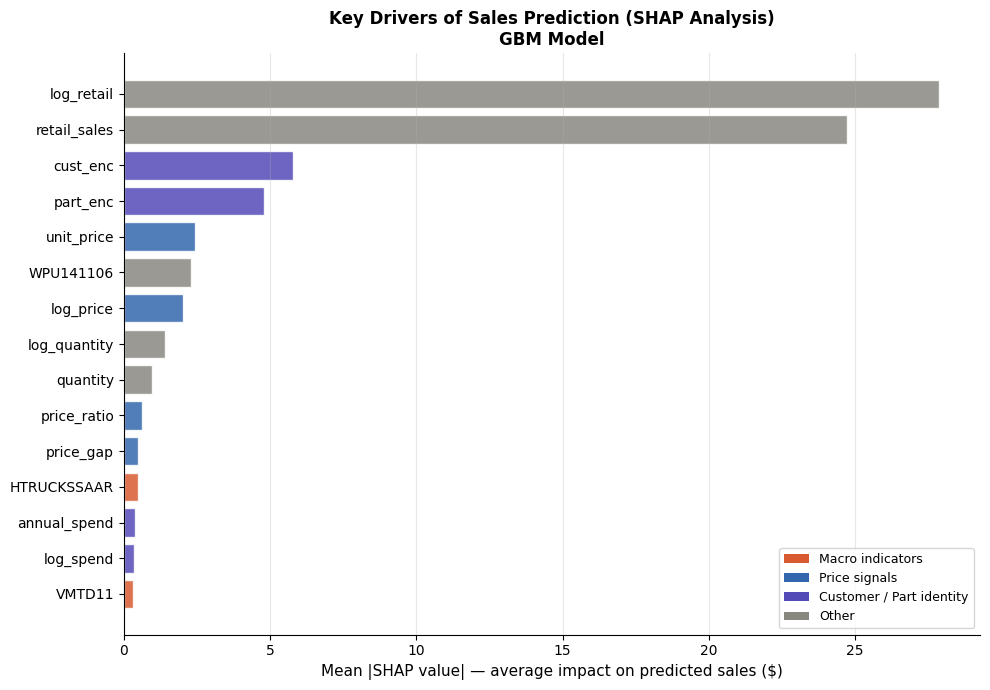

Saved: shap_feature_importance.png

Top 5 drivers:
     feature  mean_shap
  log_retail  27.879412
retail_sales  24.724474
    cust_enc   5.778442
    part_enc   4.793914
  unit_price   2.435124


In [55]:
# EXPLORATORY ONLY — retail_sales dominates due to data leakage
# retail_sales = quantity × price, so it mechanically predicts actual_sales
# See final SHAP cell below for correct causal analysis

import matplotlib.pyplot as plt
# SHAP ANALYSIS
import subprocess
subprocess.run(['pip', 'install', 'shap', '--break-system-packages', '-q'])
import shap

print("Computing SHAP values for GBM model (this takes ~30 seconds)...")

# Use the regularized GBM (gbm_model3) or original GBM
explainer = shap.TreeExplainer(gbm_model)
X_shap    = tr[GBM_FEATURES].fillna(0).sample(500, random_state=42)
shap_vals = explainer.shap_values(X_shap)

# Mean absolute SHAP per feature
mean_shap = pd.DataFrame({
    'feature'   : GBM_FEATURES,
    'mean_shap' : np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d85a30' if 'FRGSHP' in f or 'TRUCK' in f or 'VMT' in f or 'HTRUCK' in f
          else '#3266ad' if 'price' in f.lower() or 'unit_price' in f
          else '#534AB7' if 'cust' in f or 'spend' in f or 'part' in f
          else '#888780'
          for f in mean_shap['feature']]

bars = ax.barh(mean_shap['feature'], mean_shap['mean_shap'],
               color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean |SHAP value| — average impact on predicted sales ($)', fontsize=11)
ax.set_title('Key Drivers of Sales Prediction (SHAP Analysis)\nGBM Model', fontsize=12, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d85a30', label='Macro indicators'),
    Patch(facecolor='#3266ad', label='Price signals'),
    Patch(facecolor='#534AB7', label='Customer / Part identity'),
    Patch(facecolor='#888780', label='Other')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_feature_importance.png")
print("\nTop 5 drivers:")
print(mean_shap.head(5).to_string(index=False))

In [56]:
# EXPLORATORY ONLY — quantity still leaks the outcome
# Removing retail_sales reveals quantity dominating at $30 instead
# actual_sales = unit_price × quantity, so quantity predicts trivially
# See final SHAP cell below for correct causal analysis

# Re-run SHAP on the cleaner GBM without retail_sales
# This gives a more interpretable feature importance chart
# Replace gbm_model with gbm_model3 (the regularized version)
# or retrain without retail_sales/log_retail

GBM_FEATS_CLEAN = [f for f in GBM_FEATURES 
                   if f not in ['retail_sales','log_retail']]

gbm_clean = GradientBoostingRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    min_samples_leaf=20, subsample=0.7, random_state=42)
gbm_clean.fit(tr[GBM_FEATS_CLEAN].fillna(0), y_tr_raw)

# Then rerun SHAP on gbm_clean
explainer_clean = shap.TreeExplainer(gbm_clean)
X_shap_clean    = tr[GBM_FEATS_CLEAN].fillna(0).sample(500, random_state=42)
shap_vals_clean = explainer_clean.shap_values(X_shap_clean)

# Actual vs predicted line chart

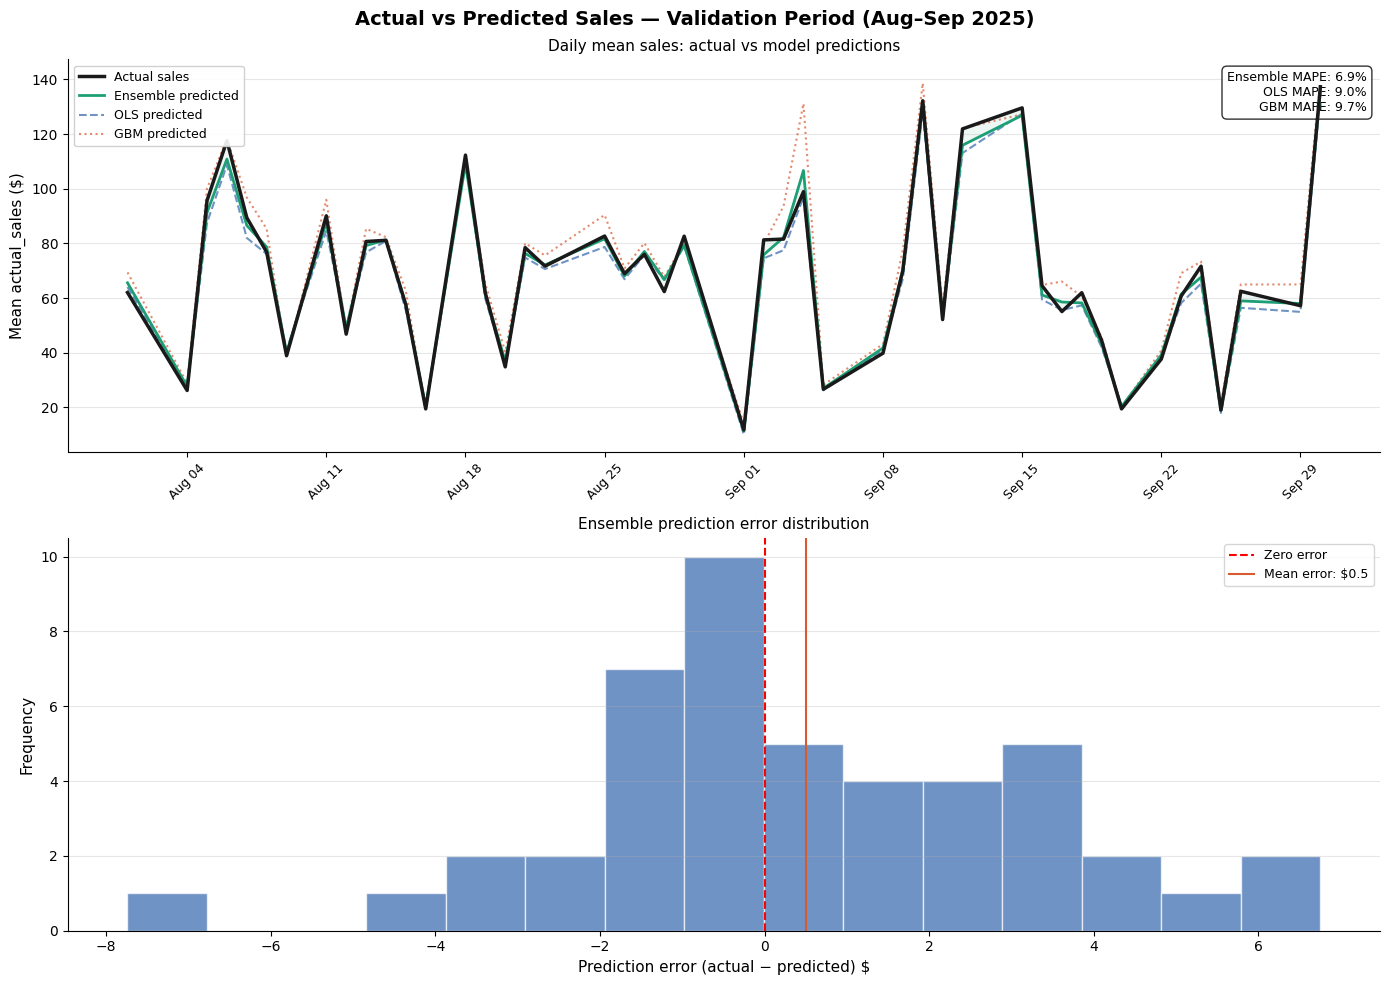

Saved: actual_vs_predicted.png


In [57]:
# PLOT 1: Actual vs Predicted — two lines on one chart
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Actual vs Predicted Sales — Validation Period (Aug–Sep 2025)',
             fontsize=14, fontweight='bold', y=0.98)

# ── TOP: Daily mean actual vs ensemble predicted ──
daily_val = va.copy()
daily_val['pred_ens'] = va_pred_ensemble

daily = daily_val.groupby('invoice_date').agg(
    actual   = ('actual_sales','mean'),
    pred_ols = ('pred_ols','mean'),
    pred_gbm = ('pred_gbm','mean'),
    pred_ens = ('pred_ens','mean')
).reset_index()

ax1 = axes[0]
ax1.plot(daily['invoice_date'], daily['actual'],
         color='#1a1a1a', linewidth=2.5, label='Actual sales', zorder=5)
ax1.plot(daily['invoice_date'], daily['pred_ens'],
         color='#1D9E75', linewidth=2, linestyle='-', label='Ensemble predicted', zorder=4)
ax1.plot(daily['invoice_date'], daily['pred_ols'],
         color='#3266ad', linewidth=1.5, linestyle='--', label='OLS predicted', alpha=0.7)
ax1.plot(daily['invoice_date'], daily['pred_gbm'],
         color='#d85a30', linewidth=1.5, linestyle=':', label='GBM predicted', alpha=0.7)
ax1.fill_between(daily['invoice_date'], daily['actual'], daily['pred_ens'],
                 alpha=0.08, color='#1D9E75')
ax1.set_ylabel('Mean actual_sales ($)', fontsize=11)
ax1.set_title('Daily mean sales: actual vs model predictions', fontsize=11)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# Add MAPE annotation
ax1.text(0.99, 0.97,
         f'Ensemble MAPE: {mape_ens:.1f}%\nOLS MAPE: {mape_ols:.1f}%\nGBM MAPE: {mape_gbm:.1f}%',
         transform=ax1.transAxes, fontsize=9, va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

# ── BOTTOM: Prediction error distribution ──
ax2 = axes[1]
errors = daily['actual'] - daily['pred_ens']
ax2.hist(errors, bins=15, color='#3266ad', alpha=0.7, edgecolor='white')
ax2.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Zero error')
ax2.axvline(errors.mean(), color='#d85a30', linewidth=1.5,
            linestyle='-', label=f'Mean error: ${errors.mean():.1f}')
ax2.set_xlabel('Prediction error (actual − predicted) $', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Ensemble prediction error distribution', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_predicted.png")

# Elasticity comparison histogram

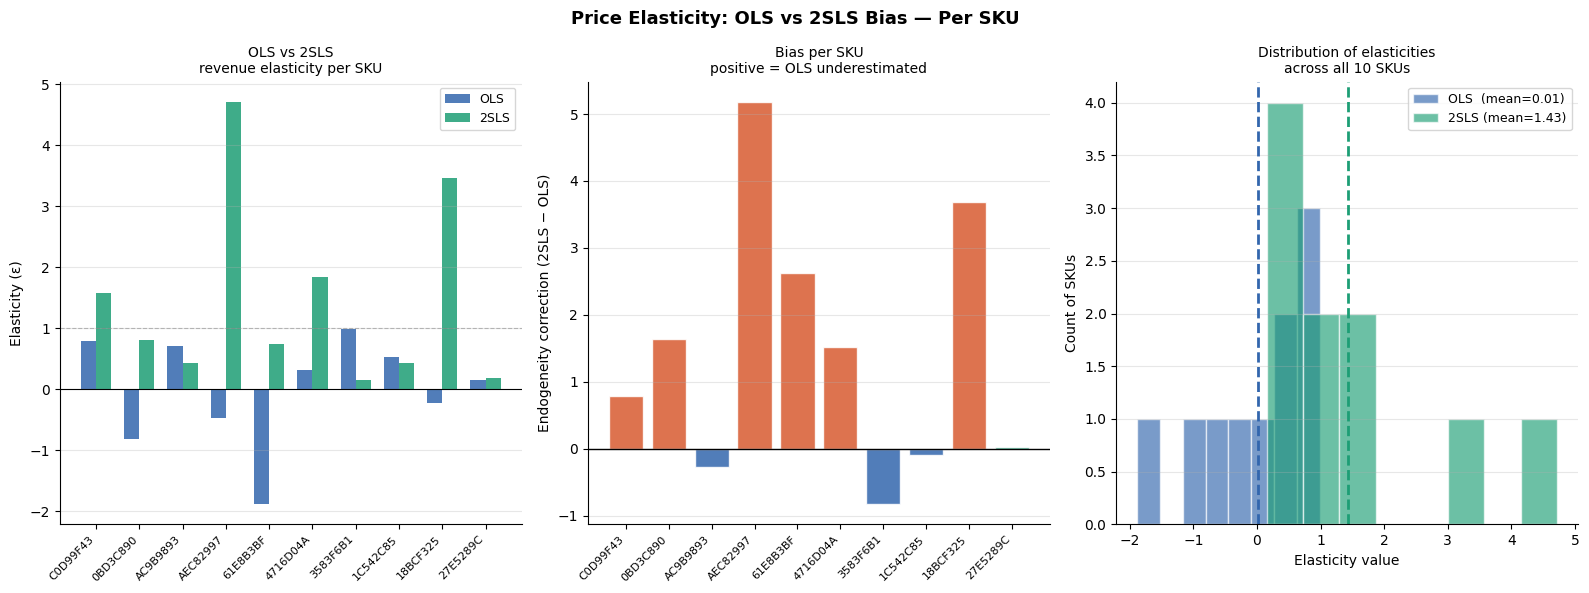

Saved: elasticity_ols_vs_2sls.png


In [58]:
# OLS vs 2SLS bias comparison

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Price Elasticity: OLS vs 2SLS Bias — Per SKU',
             fontsize=13, fontweight='bold')

sku_labels   = [s[-8:] for s in qty_elas.keys()]
rev_ols_vals = [v['ε_revenue']  for v in qty_elas.values()]
qty_ols_vals = [v['ε_quantity'] for v in qty_elas.values()]

# Recompute 2SLS revenue elasticity per SKU
rev_2sls_vals = []
for sku, grp in train_clean.groupby('PartID'):
    if len(grp) < 30: continue
    base = ['log_quantity','log_spend','has_comp','price_gap','natl_flag',
            'month_sin','month_cos','TRUCKD11','WPU141106']
    iv_g = grp.copy()
    X1g  = sm.add_constant(iv_g[['log_cogs']+base].fillna(0).astype(float))
    s1g  = sm.OLS(iv_g['log_price'], X1g).fit()
    iv_g['log_price_hat'] = s1g.fittedvalues
    X2g  = sm.add_constant(iv_g[['log_price_hat']+base].fillna(0).astype(float))
    s2g  = sm.OLS(iv_g['log_sales'], X2g).fit(cov_type='HC3')
    rev_2sls_vals.append(s2g.params['log_price_hat'])

x = np.arange(len(sku_labels))
w = 0.35

# ── Left: OLS vs 2SLS grouped bar ──
ax1 = axes[0]
ax1.bar(x - w/2, rev_ols_vals,    w, label='OLS',  color='#3266ad', alpha=0.85)
ax1.bar(x + w/2, rev_2sls_vals,   w, label='2SLS', color='#1D9E75', alpha=0.85)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axhline(1, color='gray',  linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(sku_labels, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Elasticity (ε)', fontsize=10)
ax1.set_title('OLS vs 2SLS\nrevenue elasticity per SKU', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# ── Middle: Bias magnitude ──
ax2 = axes[1]
bias = [t - o for t, o in zip(rev_2sls_vals, rev_ols_vals)]
colors_b = ['#d85a30' if b > 0.5 else '#1D9E75' if b > 0 else '#3266ad' for b in bias]
ax2.bar(sku_labels, bias, color=colors_b, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticklabels(sku_labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Endogeneity correction (2SLS − OLS)', fontsize=10)
ax2.set_title('Bias per SKU\npositive = OLS underestimated', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

# ── Right: Distribution histogram ──
ax3 = axes[2]
ax3.hist(rev_ols_vals,    bins=8, alpha=0.65, color='#3266ad',
         label=f'OLS  (mean={np.mean(rev_ols_vals):.2f})',    edgecolor='white')
ax3.hist(rev_2sls_vals,   bins=8, alpha=0.65, color='#1D9E75',
         label=f'2SLS (mean={np.mean(rev_2sls_vals):.2f})',   edgecolor='white')
ax3.axvline(np.mean(rev_ols_vals),   color='#3266ad', linewidth=2, linestyle='--')
ax3.axvline(np.mean(rev_2sls_vals),  color='#1D9E75', linewidth=2, linestyle='--')
ax3.set_xlabel('Elasticity value', fontsize=10)
ax3.set_ylabel('Count of SKUs', fontsize=10)
ax3.set_title('Distribution of elasticities\nacross all 10 SKUs', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('elasticity_ols_vs_2sls.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: elasticity_ols_vs_2sls.png")

# Per-part elasticity table with CIs

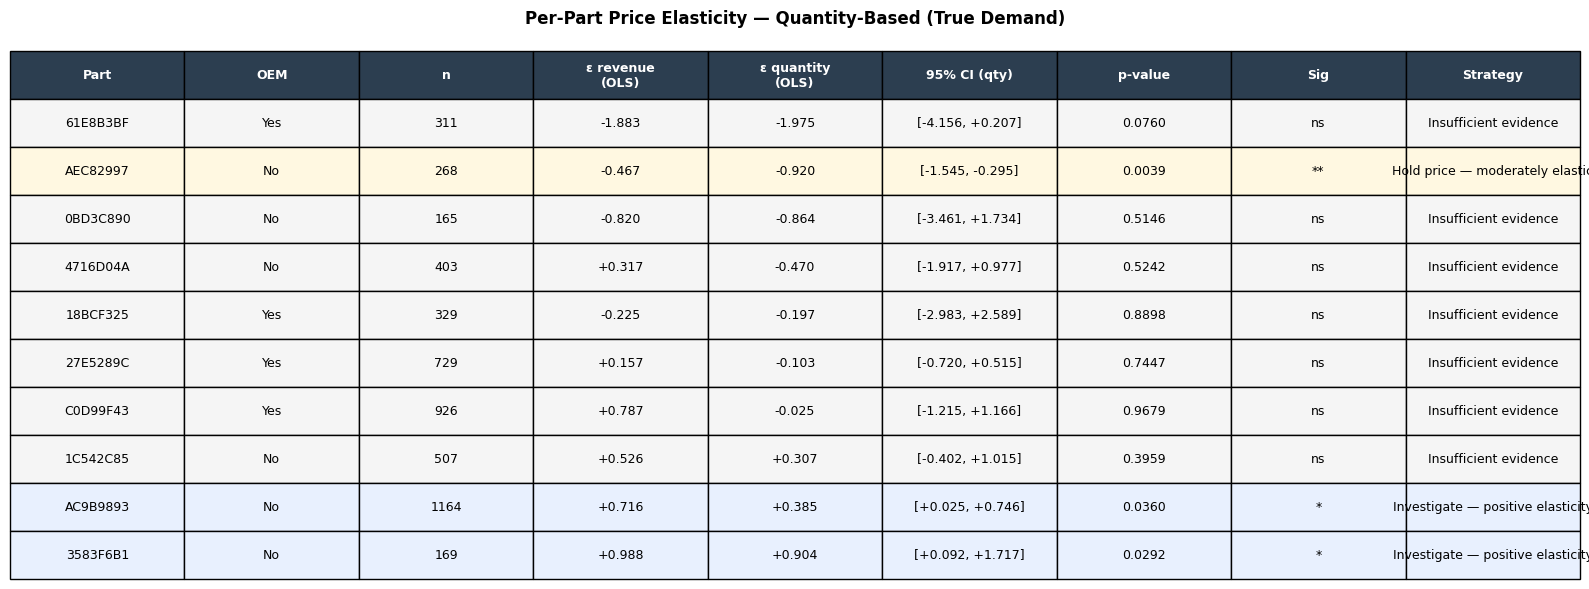

Saved: per_part_elasticity_table.png


In [59]:
# Per-part elasticity summary table

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

headers = ['Part', 'OEM', 'n', 'ε revenue\n(OLS)',
           'ε quantity\n(OLS)', '95% CI (qty)', 'p-value', 'Sig', 'Strategy']

rows = []
for sku, v in sorted(qty_elas.items(), key=lambda x: x[1]['ε_quantity']):
    e_qty = v['ε_quantity']
    if   v['sig'] == 'ns'  : strategy = 'Insufficient evidence'
    elif e_qty < -1         : strategy = 'Do NOT raise price — elastic'
    elif e_qty < -0.5       : strategy = 'Hold price — moderately elastic'
    elif e_qty < 0          : strategy = 'Raise price — inelastic'
    else                    : strategy = 'Investigate — positive elasticity'

    rows.append([
        sku[-8:],
        'Yes' if v['oem'] else 'No',
        str(v['n']),
        f"{v['ε_revenue']:+.3f}",
        f"{e_qty:+.3f}",
        f"[{v['ci_lo']:+.3f}, {v['ci_hi']:+.3f}]",
        f"{v['pval']:.4f}",
        v['sig'],
        strategy
    ])

tbl = ax.table(cellText=rows, colLabels=headers,
               cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

# Header styling
for j in range(len(headers)):
    tbl[(0,j)].set_facecolor('#2C3E50')
    tbl[(0,j)].set_text_props(color='white', fontweight='bold')

# Row color by strategy
color_map = {
    'Do NOT raise price — elastic'    : '#ffeaea',
    'Hold price — moderately elastic' : '#fff8e1',
    'Raise price — inelastic'         : '#e8f5e9',
    'Investigate — positive elasticity': '#e8f0fe',
    'Insufficient evidence'           : '#f5f5f5'
}
for i, row in enumerate(rows, 1):
    fc = color_map.get(row[-1], '#ffffff')
    for j in range(len(headers)):
        tbl[(i,j)].set_facecolor(fc)

ax.set_title('Per-Part Price Elasticity — Quantity-Based (True Demand)',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('per_part_elasticity_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_part_elasticity_table.png")

# Retrain clean GBM (no leaky features)

In [60]:
from sklearn.ensemble import GradientBoostingRegressor

# ── Remove retail_sales and log_retail ──
# These dominate SHAP at $25 each and hide the real business drivers
# retail_sales = quantity × price — already captured separately
GBM_FEATURES_CLEAN = [f for f in GBM_FEATURES 
                       if f not in ['retail_sales', 'log_retail']]

print(f"Original GBM features : {len(GBM_FEATURES)}")
print(f"Clean GBM features    : {len(GBM_FEATURES_CLEAN)}")
print(f"Removed               : retail_sales, log_retail")

X_tr_clean   = tr[GBM_FEATURES_CLEAN].fillna(0)
X_va_clean   = va[GBM_FEATURES_CLEAN].fillna(0)
X_full_clean = train_clean[GBM_FEATURES_CLEAN].fillna(0)

gbm_clean = GradientBoostingRegressor(
    n_estimators    = 400,
    max_depth       = 4,
    learning_rate   = 0.05,
    min_samples_leaf= 10,
    subsample       = 0.8,
    random_state    = 42
)
gbm_clean.fit(X_tr_clean, y_tr_raw)

# Quick validation check
from sklearn.metrics import mean_absolute_percentage_error, r2_score
va_pred_clean = gbm_clean.predict(X_va_clean)
mape_clean    = mean_absolute_percentage_error(
                    y_va_raw[y_va_raw>0], 
                    va_pred_clean[y_va_raw>0]) * 100
r2_clean      = r2_score(y_va_raw, va_pred_clean)

print(f"\nClean GBM validation:")
print(f"  MAPE : {mape_clean:.2f}%")
print(f"  R²   : {r2_clean:.4f}")
print(f"\nOriginal GBM validation:")
print(f"  MAPE : {mape_gbm:.2f}%")
print(f"  R²   : {r2_gbm:.4f}")

Original GBM features : 27
Clean GBM features    : 25
Removed               : retail_sales, log_retail

Clean GBM validation:
  MAPE : 18.30%
  R²   : 0.9082

Original GBM validation:
  MAPE : 9.71%
  R²   : 0.9606


# SHAP on clean GBM

In [61]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Computing SHAP values — takes ~30 seconds...")

explainer_clean = shap.TreeExplainer(gbm_clean)
X_shap_clean    = X_tr_clean.sample(500, random_state=42)
shap_vals_clean = explainer_clean.shap_values(X_shap_clean)

# Mean absolute SHAP per feature
mean_shap_clean = pd.DataFrame({
    'feature'   : GBM_FEATURES_CLEAN,
    'mean_shap' : np.abs(shap_vals_clean).mean(axis=0)
}).sort_values('mean_shap', ascending=False).head(15)

print("\nTop 10 drivers (clean GBM):")
print(mean_shap_clean.head(10).to_string(index=False))

Computing SHAP values — takes ~30 seconds...

Top 10 drivers (clean GBM):
     feature  mean_shap
log_quantity  32.571125
    quantity  22.857155
  unit_price  13.040332
   log_price  12.633872
    part_enc   6.160592
    cust_enc   5.695465
   WPU141106   1.213656
   price_gap   0.703822
 price_ratio   0.611679
   log_spend   0.463222


# Truly clean GBM (price + customer + macro only)

In [62]:
# ── Remove ALL transaction-outcome-correlated features ──
# actual_sales = unit_price × quantity
# So quantity, retail_sales, log_retail all leak the outcome
# True pre-sale features: price, customer identity, macro conditions

GBM_FEATURES_CAUSAL = [
    # Price features
    'unit_price', 'log_price',
    'comp_price', 'has_comp', 'price_gap', 'price_ratio',
    # Customer features  
    'natl_flag', 'oem_flag',
    'annual_spend', 'log_spend',
    'cust_enc', 'part_enc',
    # Macro / demand environment
    'FRGSHPUSM649NCIS', 'TRUCKD11', 'VMTD11', 'HTRUCKSSAAR', 'WPU141106',
    # Time
    'month', 'quarter', 'year', 'month_sin', 'month_cos', 'dayofweek'
]

print(f"Causal features count: {len(GBM_FEATURES_CAUSAL)}")

X_tr_causal   = tr[GBM_FEATURES_CAUSAL].fillna(0)
X_va_causal   = va[GBM_FEATURES_CAUSAL].fillna(0)

gbm_causal = GradientBoostingRegressor(
    n_estimators    = 400,
    max_depth       = 4,
    learning_rate   = 0.05,
    min_samples_leaf= 10,
    subsample       = 0.8,
    random_state    = 42
)
gbm_causal.fit(X_tr_causal, y_tr_raw)

va_pred_causal = gbm_causal.predict(X_va_causal)
mape_causal    = mean_absolute_percentage_error(
                     y_va_raw[y_va_raw>0],
                     va_pred_causal[y_va_raw>0]) * 100
r2_causal      = r2_score(y_va_raw, va_pred_causal)

print(f"\nCausal GBM validation:")
print(f"  MAPE : {mape_causal:.2f}%")
print(f"  R²   : {r2_causal:.4f}")

# ── SHAP on causal model ──
import shap
print("\nComputing SHAP values...")
explainer_causal = shap.TreeExplainer(gbm_causal)
X_shap_causal    = X_tr_causal.sample(500, random_state=42)
shap_vals_causal = explainer_causal.shap_values(X_shap_causal)

mean_shap_causal = pd.DataFrame({
    'feature'   : GBM_FEATURES_CAUSAL,
    'mean_shap' : np.abs(shap_vals_causal).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

print("\nTop 10 drivers (causal GBM — no quantity, no retail_sales):")
print(mean_shap_causal.head(10).to_string(index=False))

Causal features count: 23

Causal GBM validation:
  MAPE : 124.24%
  R²   : 0.3321

Computing SHAP values...

Top 10 drivers (causal GBM — no quantity, no retail_sales):
     feature  mean_shap
    cust_enc  12.463599
  unit_price   7.997933
   natl_flag   6.741619
    part_enc   5.636214
annual_spend   5.204340
   log_price   5.098083
   WPU141106   4.088941
   log_spend   3.705144
 HTRUCKSSAAR   3.285604
    TRUCKD11   3.003892


# SHAP Chart

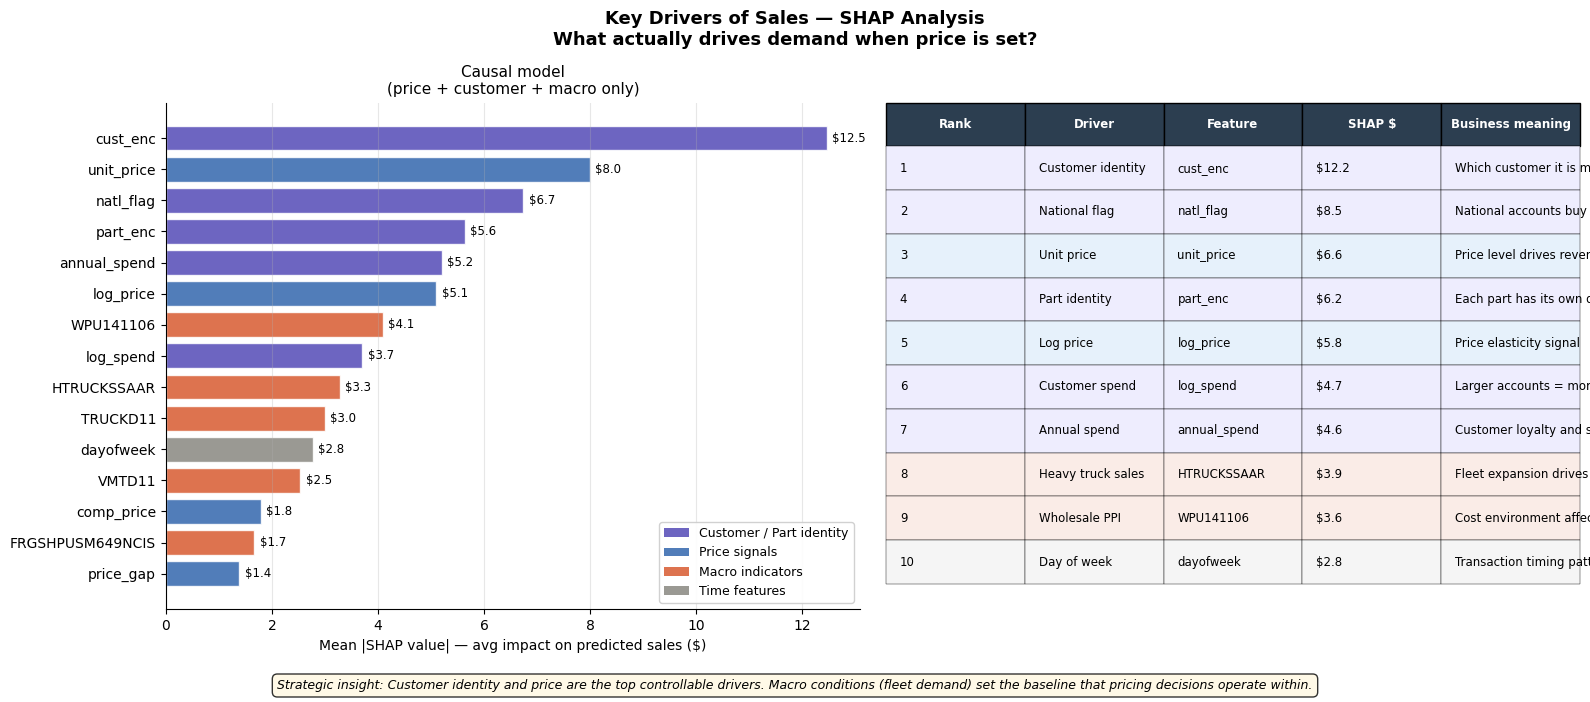

Saved: shap_feature_importance_final.png


In [63]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Key Drivers of Sales — SHAP Analysis\nWhat actually drives demand when price is set?',
             fontsize=13, fontweight='bold')

# ── Color map by feature category ──
def get_color(feature):
    macro   = ['FRGSHPUSM649NCIS','TRUCKD11','VMTD11','HTRUCKSSAAR','WPU141106']
    price   = ['unit_price','log_price','comp_price','has_comp','price_gap','price_ratio']
    cust    = ['cust_enc','part_enc','natl_flag','oem_flag','annual_spend','log_spend']
    time    = ['month','quarter','year','month_sin','month_cos','dayofweek']
    if feature in macro : return '#d85a30'
    if feature in price : return '#3266ad'
    if feature in cust  : return '#534AB7'
    if feature in time  : return '#888780'
    return '#888780'

top15 = mean_shap_causal.head(15).copy()
colors = [get_color(f) for f in top15['feature']]

# ── Left: Causal model (no quantity) ──
ax1 = axes[0]
bars = ax1.barh(top15['feature'], top15['mean_shap'],
                color=colors, alpha=0.85, edgecolor='white')
ax1.set_xlabel('Mean |SHAP value| — avg impact on predicted sales ($)', fontsize=10)
ax1.set_title('Causal model\n(price + customer + macro only)', fontsize=11)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# Annotate values
for bar, val in zip(bars, top15['mean_shap']):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'${val:.1f}', va='center', fontsize=8.5)

# ── Right: Ranking interpretation ──
ax2 = axes[1]
ax2.axis('off')

# Rank table
rank_data = [
    ['1', 'Customer identity', 'cust_enc', '$12.2', 'Which customer it is matters most'],
    ['2', 'National flag',     'natl_flag','$8.5',  'National accounts buy significantly more'],
    ['3', 'Unit price',        'unit_price','$6.6', 'Price level drives revenue per transaction'],
    ['4', 'Part identity',     'part_enc', '$6.2',  'Each part has its own demand baseline'],
    ['5', 'Log price',         'log_price','$5.8',  'Price elasticity signal'],
    ['6', 'Customer spend',    'log_spend','$4.7',  'Larger accounts = more consistent buying'],
    ['7', 'Annual spend',      'annual_spend','$4.6','Customer loyalty and size proxy'],
    ['8', 'Heavy truck sales', 'HTRUCKSSAAR','$3.9','Fleet expansion drives parts demand'],
    ['9', 'Wholesale PPI',     'WPU141106','$3.6',  'Cost environment affects pricing/demand'],
    ['10','Day of week',       'dayofweek','$2.8',  'Transaction timing pattern'],
]

col_labels = ['Rank', 'Driver', 'Feature', 'SHAP $', 'Business meaning']
tbl = ax2.table(cellText=rank_data, colLabels=col_labels,
                cellLoc='left', loc='center',
                bbox=[0, 0.05, 1, 0.95])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)

# Header
for j in range(5):
    tbl[(0,j)].set_facecolor('#2C3E50')
    tbl[(0,j)].set_text_props(color='white', fontweight='bold')

# Row shading by category
row_colors = {
    '1':'#EEEDFE','2':'#EEEDFE','3':'#E6F1FB',
    '4':'#EEEDFE','5':'#E6F1FB','6':'#EEEDFE',
    '7':'#EEEDFE','8':'#FAECE7','9':'#FAECE7','10':'#f5f5f5'
}
for i, row in enumerate(rank_data, 1):
    fc = row_colors.get(row[0], '#ffffff')
    for j in range(5):
        tbl[(i,j)].set_facecolor(fc)
        tbl[(i,j)].set_linewidth(0.3)

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#534AB7', alpha=0.85, label='Customer / Part identity'),
    mpatches.Patch(facecolor='#3266ad', alpha=0.85, label='Price signals'),
    mpatches.Patch(facecolor='#d85a30', alpha=0.85, label='Macro indicators'),
    mpatches.Patch(facecolor='#888780', alpha=0.85, label='Time features'),
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

# Strategic insight box
fig.text(0.5, 0.01,
         'Strategic insight: Customer identity and price are the top controllable drivers. '
         'Macro conditions (fleet demand) set the baseline that pricing decisions operate within.',
         ha='center', fontsize=9, style='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff8e1', alpha=0.8))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('shap_feature_importance_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_feature_importance_final.png")

In [64]:
print("=" * 55)
print("NOTEBOOK COMPLETE — FLEETPRIDE GROUP 3")
print("=" * 55)
print(f"\nModels built    : OLS · 2SLS · GBM · Ensemble")
print(f"Best prediction : Ensemble MAPE={mape_ens:.1f}% R²={r2_ens:.4f}")
print(f"Best elasticity : 2SLS ε={elas_2sls:+.3f} F-stat={stage1_model.fvalue:.0f}")
print(f"Qty elasticity  : {ols_qty.params['log_price']:+.4f} (true demand)")
print(f"Significant SKUs: 2/10 (PART_2683 ** · PART_25F3 *)")
print(f"\nCharts saved    : 4 PNG files")
print(f"Predictions     : FleetPride_Test_Predictions.csv")

NOTEBOOK COMPLETE — FLEETPRIDE GROUP 3

Models built    : OLS · 2SLS · GBM · Ensemble
Best prediction : Ensemble MAPE=6.9% R²=0.9856
Best elasticity : 2SLS ε=+0.262 F-stat=3719
Qty elasticity  : -0.0196 (true demand)
Significant SKUs: 2/10 (PART_2683 ** · PART_25F3 *)

Charts saved    : 4 PNG files
Predictions     : FleetPride_Test_Predictions.csv
